# Modelo Supervisado — Predicción de Producción Futura

## Objetivo

El objetivo de esta etapa es construir un dataset de modelado orientado a predecir la producción futura de petróleo de pozos maduros de la Cuenca Cuyana.

A partir de los resultados obtenidos en el EDA, se trabajará únicamente con registros compatibles con producción continua, evitando incorporar períodos asociados a abandono, reparación, estudio, paradas operativas u otras situaciones que puedan distorsionar el comportamiento productivo normal del pozo.

El enfoque seleccionado para la predicción será **directo por horizonte**, donde se entrenarán modelos independientes para predecir producción a 1, 2, 3, 4, 5 y 6 meses hacia adelante.

Antes de construir variables temporales y targets, primero se definirá formalmente el universo de pozos maduros aptos para el modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
RUTA_DATOS = "../data/processed/produccion_pozos_cuenca_cuyana_2021_2026.csv"

df = pd.read_csv(RUTA_DATOS)

df["fecha_data"] = pd.to_datetime(df["fecha_data"])

df_cuyana = df[df["cuenca"] == "CUYANA"].copy()

print("Filas:", len(df_cuyana))
print("Pozos únicos:", df_cuyana["idpozo"].nunique())
print("Desde:", df_cuyana["fecha_data"].min())
print("Hasta:", df_cuyana["fecha_data"].max())

Filas: 246240
Pozos únicos: 3702
Desde: 2021-01-31 00:00:00
Hasta: 2026-08-31 00:00:00


# 1. Definir dataset de pozos maduros con producción continua

## 1.1 Revisión de estados operativos

In [3]:
df_cuyana["tipoestado"].value_counts(dropna=False)

tipoestado
Abandonado                            75936
Extracción Efectiva                   64195
A Abandonar                           19256
En Inyección Efectiva                 18502
Parado Alta Relación Agua/Petróleo    15451
En Estudio                            14521
En Reserva para Recup. Sec./Asist.    13054
En Espera de Reparación               11720
Parado Transitoriamente               10620
Abandono Temporario                    1968
Otras Situación Inactivo                937
En Reparación                            62
Otras Situación Activo                   18
Name: count, dtype: int64

### Observación

La distribución de `tipoestado` muestra una gran cantidad de registros asociados a situaciones no productivas, como `Abandonado`, `A Abandonar`, `En Estudio`, `En Espera de Reparación` y `Parado Transitoriamente`.

Por este motivo, la presencia de un pozo en el dataset no puede interpretarse automáticamente como actividad productiva.

## 1.2 Relación entre estado operativo y producción de petróleo

In [4]:
estado_prod = (
    df_cuyana
    .groupby("tipoestado")
    .agg(
        registros=("idpozo", "size"),
        pozos=("idpozo", "nunique"),
        prod_pet_media=("prod_pet", "mean"),
        prod_pet_mediana=("prod_pet", "median"),
        pct_prod_pet_positiva=("prod_pet", lambda x: (x > 0).mean() * 100)
    )
    .sort_values("registros", ascending=False)
)

estado_prod.round(2)

,registros,pozos,prod_pet_media,prod_pet_mediana,pct_prod_pet_positiva
tipoestado,,,,,
Abandonado,75936,1340,0.00,0.00,0.00
Extracción Efectiva,64195,1223,84.17,63.57,88.67
A Abandonar,19256,761,0.00,0.00,0.01
En Inyección Efectiva,18502,409,0.01,0.00,0.02
Parado Alta Relación Agua/Petróleo,15451,331,0.00,0.00,0.03
En Estudio,14521,432,0.02,0.00,0.06
En Reserva para Recup. Sec./Asist.,13054,341,0.01,0.00,0.01
En Espera de Reparación,11720,364,0.00,0.00,0.04
Parado Transitoriamente,10620,1017,3.62,0.00,5.46


### Observación

El estado `Extracción Efectiva` se diferencia claramente del resto:

- contiene 64.195 registros;
- comprende 1.223 pozos;
- presenta una producción media aproximada de 84,17 m³;
- una mediana aproximada de 63,57 m³;
- y el 88,67% de sus registros presenta producción de petróleo positiva.

En cambio, la mayoría de los estados asociados a abandono, reparación, estudio o parada presentan una mediana de producción igual a 0 y porcentajes de producción positiva cercanos a 0%.

Por lo tanto, `Extracción Efectiva` se adopta como el estado operativo de referencia para identificar períodos productivos.

## 1.3 Historial productivo general por pozo

In [5]:
historial_pozos = (
    df_cuyana
    .groupby("idpozo")
    .agg(
        meses_totales=("fecha_data", "nunique"),
        meses_prod_positiva=("prod_pet", lambda x: (x > 0).sum()),
        primera_fecha=("fecha_data", "min"),
        ultima_fecha=("fecha_data", "max")
    )
)

historial_pozos["pct_meses_prod_positiva"] = (
    historial_pozos["meses_prod_positiva"] /
    historial_pozos["meses_totales"] * 100
)

historial_pozos.describe()

,meses_totales,meses_prod_positiva,primera_fecha,ultima_fecha,pct_meses_prod_positiva
count,3702.000000,3702.000000,3702,3702,3702.000000
mean,66.515397,15.539708,2021-02-09 17:57:04.959481,2026-07-26 17:18:11.085899,23.370405
min,4.000000,0.000000,2021-01-31 00:00:00,2022-04-30 00:00:00,0.000000
25%,67.000000,0.000000,2021-01-31 00:00:00,2026-07-31 00:00:00,0.000000
50%,67.000000,0.000000,2021-01-31 00:00:00,2026-07-31 00:00:00,0.000000
75%,67.000000,26.750000,2021-01-31 00:00:00,2026-07-31 00:00:00,41.791045
max,68.000000,68.000000,2026-05-31 00:00:00,2026-08-31 00:00:00,100.000000
std,4.770967,26.256841,NaN,NaN,39.318476


### Observación

El historial completo muestra que muchos pozos permanecen registrados durante gran parte del período analizado, pero no necesariamente producen petróleo de forma continua.

Aunque la cantidad de meses observados por pozo es alta, la mediana de meses con producción positiva es 0.

Esto confirma que el historial completo no puede utilizarse directamente para definir madurez productiva.

## 1.4 Historial restringido a `Extracción Efectiva`

In [6]:
df_extraccion = df_cuyana[
    df_cuyana["tipoestado"] == "Extracción Efectiva"
].copy()

historial_extraccion = (
    df_extraccion
    .groupby("idpozo")
    .agg(
        meses_extraccion=("fecha_data", "nunique"),
        meses_pet_positiva=("prod_pet", lambda x: (x > 0).sum()),
        prod_pet_media=("prod_pet", "mean"),
        prod_pet_mediana=("prod_pet", "median"),
        primera_fecha=("fecha_data", "min"),
        ultima_fecha=("fecha_data", "max")
    )
)

historial_extraccion["pct_pet_positiva"] = (
    historial_extraccion["meses_pet_positiva"]
    / historial_extraccion["meses_extraccion"]
    * 100
)

historial_extraccion.describe()

,meses_extraccion,meses_pet_positiva,prod_pet_media,prod_pet_mediana,primera_fecha,ultima_fecha,pct_pet_positiva
count,1223.000000,1223.000000,1223.000000,1223.000000,1223,1223,1223.000000
mean,52.489779,46.542927,76.972744,76.689185,2021-04-29 01:14:10.695012,2025-11-08 01:13:00.049059,88.072622
min,1.000000,0.000000,0.000000,0.000000,2021-01-31 00:00:00,2021-01-31 00:00:00,0.000000
25%,42.000000,26.500000,26.436954,25.966455,2021-01-31 00:00:00,2025-12-31 00:00:00,98.039216
50%,64.000000,60.000000,60.644375,61.220000,2021-01-31 00:00:00,2026-07-31 00:00:00,100.000000
75%,67.000000,67.000000,105.276543,104.257500,2021-01-31 00:00:00,2026-07-31 00:00:00,100.000000
max,68.000000,68.000000,950.951776,1002.930000,2026-05-31 00:00:00,2026-08-31 00:00:00,100.000000
std,20.163400,24.636266,77.808455,78.549129,NaN,NaN,30.324444


### Observación

Dentro de `Extracción Efectiva`, el comportamiento es mucho más consistente:

- se identificaron 1.223 pozos;
- la mediana es de 64 meses en extracción efectiva;
- la mediana del porcentaje de meses con producción positiva es 100%.

Esto confirma que este subconjunto es más adecuado para definir pozos maduros.

## 1.5 Evaluación de criterios de madurez

In [7]:
for meses in [6, 12, 18, 24, 36]:
    cantidad = (historial_extraccion["meses_extraccion"] >= meses).sum()
    print(f"Pozos con al menos {meses} meses en Extracción Efectiva: {cantidad}")

Pozos con al menos 6 meses en Extracción Efectiva: 1176
Pozos con al menos 12 meses en Extracción Efectiva: 1138
Pozos con al menos 18 meses en Extracción Efectiva: 1089
Pozos con al menos 24 meses en Extracción Efectiva: 1054
Pozos con al menos 36 meses en Extracción Efectiva: 960


### Observación

Incluso utilizando criterios exigentes de historial, el número de pozos disponibles sigue siendo suficiente para modelado.

Resultados:

- al menos 12 meses: 1.138 pozos;
- al menos 18 meses: 1.089 pozos;
- al menos 24 meses: 1.054 pozos;
- al menos 36 meses: 960 pozos.

Esto permite aplicar un criterio de madurez relativamente estricto sin reducir excesivamente la muestra.

In [8]:
for meses in [12, 18, 24]:
    for pct in [80, 90, 95]:
        cantidad = (
            (historial_extraccion["meses_extraccion"] >= meses) &
            (historial_extraccion["pct_pet_positiva"] >= pct)
        ).sum()

        print(
            f">= {meses} meses y >= {pct}% producción positiva: "
            f"{cantidad} pozos"
        )

>= 12 meses y >= 80% producción positiva: 1007 pozos
>= 12 meses y >= 90% producción positiva: 975 pozos
>= 12 meses y >= 95% producción positiva: 920 pozos
>= 18 meses y >= 80% producción positiva: 969 pozos
>= 18 meses y >= 90% producción positiva: 941 pozos
>= 18 meses y >= 95% producción positiva: 894 pozos
>= 24 meses y >= 80% producción positiva: 941 pozos
>= 24 meses y >= 90% producción positiva: 915 pozos
>= 24 meses y >= 95% producción positiva: 868 pozos


### Observación

Al combinar duración de historial y porcentaje de producción positiva, la muestra continúa siendo amplia.

Por ejemplo:

- al menos 24 meses y 90% de producción positiva: 915 pozos;
- al menos 24 meses y 95% de producción positiva: 868 pozos.

Sin embargo, un porcentaje elevado de meses positivos no garantiza que esos meses sean consecutivos.

Por este motivo, se realiza una validación adicional de continuidad temporal.

## 1.6 Verificación de continuidad temporal

In [9]:
df_continuos = df_cuyana[
    (df_cuyana["tipoestado"] == "Extracción Efectiva") &
    (df_cuyana["prod_pet"] > 0)
].copy()

# Representar cada fecha como año-mes
df_continuos["periodo"] = df_continuos["fecha_data"].dt.to_period("M")

# Por seguridad: una fila por pozo-mes
df_continuos = (
    df_continuos
    .sort_values(["idpozo", "periodo"])
    .drop_duplicates(["idpozo", "periodo"])
)

# Número entero del mes para detectar saltos
df_continuos["periodo_num"] = df_continuos["periodo"].astype(int)

# Diferencia respecto al mes anterior del mismo pozo
df_continuos["dif_meses"] = (
    df_continuos.groupby("idpozo")["periodo_num"].diff()
)

# Comienza una nueva racha cuando no viene inmediatamente del mes anterior
df_continuos["nuevo_bloque"] = (
    df_continuos["dif_meses"].ne(1)
)

df_continuos["bloque"] = (
    df_continuos
    .groupby("idpozo")["nuevo_bloque"]
    .cumsum()
)

# Duración de cada racha continua
rachas = (
    df_continuos
    .groupby(["idpozo", "bloque"])
    .size()
)

# Mayor racha continua de cada pozo
max_racha = (
    rachas
    .groupby("idpozo")
    .max()
    .rename("max_meses_continuos")
)

max_racha.describe()

count    1102.000000
mean       43.493648
std        22.196821
min         1.000000
25%        25.000000
50%        45.000000
75%        67.000000
max        68.000000
Name: max_meses_continuos, dtype: float64

### Observación

Las rachas continuas presentan una duración considerable:

- mediana: 45 meses consecutivos;
- percentil 25: 25 meses;
- percentil 75: 67 meses;
- máximo: 68 meses.

Esto indica que existe un conjunto amplio de pozos con trayectorias productivas largas y continuas.

In [10]:
for meses in [6, 12, 18, 24, 36]:
    cantidad = (max_racha >= meses).sum()

    print(
        f"Pozos con al menos {meses} meses consecutivos "
        f"de Extracción Efectiva y producción positiva: {cantidad}"
    )

Pozos con al menos 6 meses consecutivos de Extracción Efectiva y producción positiva: 1047
Pozos con al menos 12 meses consecutivos de Extracción Efectiva y producción positiva: 975
Pozos con al menos 18 meses consecutivos de Extracción Efectiva y producción positiva: 918
Pozos con al menos 24 meses consecutivos de Extracción Efectiva y producción positiva: 851
Pozos con al menos 36 meses consecutivos de Extracción Efectiva y producción positiva: 666


### Observación

La cantidad de pozos con continuidad suficiente es:

- al menos 6 meses consecutivos: 1.047 pozos;
- al menos 12 meses: 975;
- al menos 18 meses: 918;
- al menos 24 meses: 851;
- al menos 36 meses: 666.

Se seleccionó un mínimo de 24 meses consecutivos porque representa dos años de historial productivo continuo y mantiene una muestra amplia de 851 pozos.

In [11]:
pozos_maduros_ids = max_racha[
    max_racha >= 24
].index

df_maduros = df_cuyana[
    df_cuyana["idpozo"].isin(pozos_maduros_ids)
].copy()

print("Pozos maduros:", df_maduros["idpozo"].nunique())
print("Registros totales:", len(df_maduros))

Pozos maduros: 851
Registros totales: 56998


In [12]:
df_modelo_base = df_cuyana[
    df_cuyana["idpozo"].isin(pozos_maduros_ids)
    & (df_cuyana["tipoestado"] == "Extracción Efectiva")
    & (df_cuyana["prod_pet"] > 0)
].copy()

df_modelo_base = (
    df_modelo_base
    .sort_values(["idpozo", "fecha_data"])
    .reset_index(drop=True)
)

print("Pozos:", df_modelo_base["idpozo"].nunique())
print("Registros:", len(df_modelo_base))
print("Desde:", df_modelo_base["fecha_data"].min())
print("Hasta:", df_modelo_base["fecha_data"].max())

Pozos: 851
Registros: 51350
Desde: 2021-01-31 00:00:00
Hasta: 2026-08-31 00:00:00


## 1.7 Selección de la racha productiva principal

In [13]:
tamano_bloques = (
    df_continuos
    .groupby(["idpozo", "bloque"])
    .size()
    .reset_index(name="meses_bloque")
)

bloque_principal = (
    tamano_bloques
    .sort_values(
        ["idpozo", "meses_bloque"],
        ascending=[True, False]
    )
    .drop_duplicates("idpozo")
)

bloque_principal = bloque_principal[
    bloque_principal["meses_bloque"] >= 24
].copy()

bloque_principal.head()

,idpozo,bloque,meses_bloque
11,8380,2,66
25,8385,6,32
27,8386,2,30
32,8387,2,41
36,8388,3,30


### Observación

Para cada pozo se identificó su bloque consecutivo más largo de `Extracción Efectiva` con producción positiva.

Se conservaron únicamente los bloques cuya duración es de al menos 24 meses.

## 1.8 Construcción del dataset final

In [14]:
df_modelo_base = df_continuos.merge(
    bloque_principal[["idpozo", "bloque"]],
    on=["idpozo", "bloque"],
    how="inner"
).copy()

df_modelo_base = (
    df_modelo_base
    .sort_values(["idpozo", "fecha_data"])
    .reset_index(drop=True)
)

print("Pozos:", df_modelo_base["idpozo"].nunique())
print("Registros:", len(df_modelo_base))
print("Desde:", df_modelo_base["fecha_data"].min())
print("Hasta:", df_modelo_base["fecha_data"].max())

Pozos: 851
Registros: 44948
Desde: 2021-01-31 00:00:00
Hasta: 2026-08-31 00:00:00


### Observación

El dataset resultante contiene:

- 851 pozos maduros;
- 44.948 registros;
- información entre enero de 2021 y agosto de 2026.

Al conservar únicamente la racha continua principal de cada pozo, se evita mezclar distintos períodos productivos separados por interrupciones.

## 1.9 Validación final de continuidad

In [15]:
chequeo_continuidad = (
    df_modelo_base
    .groupby("idpozo")["periodo_num"]
    .apply(lambda x: x.sort_values().diff().dropna().eq(1).all())
)

print("Pozos con continuidad perfecta:", chequeo_continuidad.sum())
print("Pozos totales:", len(chequeo_continuidad))
print("Pozos con algún salto:", (~chequeo_continuidad).sum())

Pozos con continuidad perfecta: 851
Pozos totales: 851
Pozos con algún salto: 0


### Observación

La validación confirmó:

- 851 pozos con continuidad perfecta;
- 851 pozos totales;
- 0 pozos con saltos temporales.

Por lo tanto, el dataset seleccionado cumple con el criterio de continuidad necesario para construir variables temporales.

## 1.10 Conclusión final de la seccion 1

Se definió como **pozo maduro con producción continua** a aquel que presenta una racha de al menos **24 meses consecutivos** en estado `Extracción Efectiva`, con producción de petróleo positiva (`prod_pet > 0`) y sin interrupciones temporales dentro de la secuencia seleccionada.

El criterio fue definido a partir del análisis de:

- estado operativo;
- duración del historial;
- porcentaje de producción positiva;
- continuidad mensual real.

Luego de conservar únicamente la racha productiva continua principal de cada pozo, se obtuvo un dataset final compuesto por:

- **851 pozos maduros**;
- **44.948 registros**;
- período entre enero de 2021 y agosto de 2026;
- **0 saltos temporales** dentro de las secuencias seleccionadas.

Este dataset, denominado `df_modelo_base`, será utilizado como base para las siguientes etapas de Feature Engineering del modelo de **predicción directa por horizonte**, incluyendo lags, ventanas móviles, antigüedad productiva y targets futuros H1–H6.

### Guardado del dataset procesado

Se guarda el dataset final de pozos maduros con producción continua en `data/processed/` para utilizarlo como entrada reproducible en las siguientes etapas de Feature Engineering y modelado.

In [16]:
RUTA_MODELO_BASE = "../data/processed/pozos_maduros_extraccion_efectiva_24m.csv"

df_modelo_base.to_csv(
    RUTA_MODELO_BASE,
    index=False
)

print("Archivo guardado en:", RUTA_MODELO_BASE)

Archivo guardado en: ../data/processed/pozos_maduros_extraccion_efectiva_24m.csv


### Observación

El dataset `pozos_maduros_extraccion_efectiva_24m.csv` queda disponible como base procesada para construir lags, ventanas móviles, antigüedad productiva y targets futuros H1–H6.

# 2. Crear variables temporales — Lags

En esta etapa se construyen variables de rezago a partir de la producción histórica de petróleo de cada pozo.

Estas variables permitirán que el modelo utilice información de meses anteriores para realizar la **predicción directa por horizonte** de la producción futura.

In [17]:
RUTA_MODELO_BASE = "../data/processed/pozos_maduros_extraccion_efectiva_24m.csv"

df_fe = pd.read_csv(
    RUTA_MODELO_BASE,
    parse_dates=["fecha_data"]
)

df_fe = (
    df_fe
    .sort_values(["idpozo", "fecha_data"])
    .reset_index(drop=True)
)

print("Pozos:", df_fe["idpozo"].nunique())
print("Registros:", len(df_fe))
print("Desde:", df_fe["fecha_data"].min())
print("Hasta:", df_fe["fecha_data"].max())

Pozos: 851
Registros: 44948
Desde: 2021-01-31 00:00:00
Hasta: 2026-08-31 00:00:00


## 2.1 Preparación del dataset para Feature Engineering

### Observación

Se cargó el dataset procesado de pozos maduros con producción continua y se ordenaron los registros por `idpozo` y `fecha_data`.

El orden cronológico es necesario para construir correctamente las variables de rezago sin mezclar información entre pozos.

In [18]:
df_fe["prod_pet_lag1"] = (
    df_fe.groupby("idpozo")["prod_pet"].shift(1)
)

df_fe["prod_pet_lag2"] = (
    df_fe.groupby("idpozo")["prod_pet"].shift(2)
)

df_fe["prod_pet_lag3"] = (
    df_fe.groupby("idpozo")["prod_pet"].shift(3)
)

df_fe["prod_pet_lag6"] = (
    df_fe.groupby("idpozo")["prod_pet"].shift(6)
)

## 2.2 Construcción de variables de rezago

### Observación

Se generaron cuatro variables temporales de producción:

- `prod_pet_lag1`: producción del mes anterior;
- `prod_pet_lag2`: producción de hace 2 meses;
- `prod_pet_lag3`: producción de hace 3 meses;
- `prod_pet_lag6`: producción de hace 6 meses.

Estas variables representan el comportamiento productivo reciente de cada pozo y serán utilizadas como variables predictoras.

In [19]:
columnas_lags = [
    "idpozo",
    "fecha_data",
    "prod_pet",
    "prod_pet_lag1",
    "prod_pet_lag2",
    "prod_pet_lag3",
    "prod_pet_lag6"
]

df_fe[columnas_lags].head(15)

,idpozo,fecha_data,prod_pet,prod_pet_lag1,prod_pet_lag2,prod_pet_lag3,prod_pet_lag6
0,8380,2021-03-31,15.08,NaN,NaN,NaN,NaN
1,8380,2021-04-30,24.29,15.08,NaN,NaN,NaN
2,8380,2021-05-31,27.10,24.29,15.08,NaN,NaN
3,8380,2021-06-30,25.01,27.10,24.29,15.08,NaN
4,8380,2021-07-31,21.16,25.01,27.10,24.29,NaN
5,8380,2021-08-31,11.16,21.16,25.01,27.10,NaN
6,8380,2021-09-30,10.30,11.16,21.16,25.01,15.08
7,8380,2021-10-31,26.54,10.30,11.16,21.16,24.29
8,8380,2021-11-30,12.03,26.54,10.30,11.16,27.10
9,8380,2021-12-31,10.77,12.03,26.54,10.30,25.01


## 2.3 Verificación visual de los lags

### Observación

La inspección de los primeros registros confirma que las variables de rezago fueron construidas correctamente dentro de cada pozo.

Por ejemplo, para el pozo observado:

- `prod_pet_lag1` corresponde a la producción del mes inmediatamente anterior;
- `prod_pet_lag2` corresponde a la producción de dos meses atrás;
- `prod_pet_lag3` corresponde a la producción de tres meses atrás;
- `prod_pet_lag6` corresponde a la producción de seis meses atrás.

Los valores faltantes de las primeras filas son esperables, ya que al inicio de cada serie todavía no existe suficiente historial previo para calcular todos los rezagos.

In [20]:
columnas_lags = [
    "idpozo",
    "fecha_data",
    "prod_pet",
    "prod_pet_lag1",
    "prod_pet_lag2",
    "prod_pet_lag3",
    "prod_pet_lag6"
]

df_fe[columnas_lags].head(15)

,idpozo,fecha_data,prod_pet,prod_pet_lag1,prod_pet_lag2,prod_pet_lag3,prod_pet_lag6
0,8380,2021-03-31,15.08,NaN,NaN,NaN,NaN
1,8380,2021-04-30,24.29,15.08,NaN,NaN,NaN
2,8380,2021-05-31,27.10,24.29,15.08,NaN,NaN
3,8380,2021-06-30,25.01,27.10,24.29,15.08,NaN
4,8380,2021-07-31,21.16,25.01,27.10,24.29,NaN
5,8380,2021-08-31,11.16,21.16,25.01,27.10,NaN
6,8380,2021-09-30,10.30,11.16,21.16,25.01,15.08
7,8380,2021-10-31,26.54,10.30,11.16,21.16,24.29
8,8380,2021-11-30,12.03,26.54,10.30,11.16,27.10
9,8380,2021-12-31,10.77,12.03,26.54,10.30,25.01


### Observación

La inspección visual confirma que los rezagos fueron construidos correctamente para cada pozo.

En el ejemplo mostrado:

- `prod_pet_lag1` toma la producción del mes anterior;
- `prod_pet_lag2` toma la producción de dos meses atrás;
- `prod_pet_lag3` toma la producción de tres meses atrás;
- `prod_pet_lag6` toma la producción de seis meses atrás.

Los valores `NaN` de las primeras filas son esperables, porque al comienzo de la serie todavía no existe suficiente historial previo para calcular todos los rezagos.

## 2.4 Revisión de valores faltantes generados por los lags

In [21]:
df_fe[
    [
        "prod_pet_lag1",
        "prod_pet_lag2",
        "prod_pet_lag3",
        "prod_pet_lag6"
    ]
].isna().sum()

prod_pet_lag1     851
prod_pet_lag2    1702
prod_pet_lag3    2553
prod_pet_lag6    5106
dtype: int64

### Observación

La cantidad de valores faltantes generados por los lags coincide con lo esperado para 851 pozos:

- `prod_pet_lag1`: 851 valores faltantes;
- `prod_pet_lag2`: 1.702 valores faltantes;
- `prod_pet_lag3`: 2.553 valores faltantes;
- `prod_pet_lag6`: 5.106 valores faltantes.

Estos valores `NaN` no representan errores en los datos, sino la falta natural de historial previo en los primeros meses de cada pozo.

Por ejemplo, para calcular un rezago de 6 meses se necesitan seis observaciones anteriores, por lo que las primeras seis filas de cada pozo no pueden tener un valor válido para `prod_pet_lag6`.

## 2.5 Conclusión de la segunda seccion

Se construyeron correctamente las variables temporales de rezago para la producción de petróleo de cada pozo:

- `prod_pet_lag1`
- `prod_pet_lag2`
- `prod_pet_lag3`
- `prod_pet_lag6`

La validación visual confirmó que cada lag representa correctamente la producción histórica del mismo pozo, respetando el orden cronológico y sin mezclar información entre pozos.

Los valores faltantes observados al inicio de cada serie son esperables y se deben a la ausencia de historial previo suficiente para calcular cada rezago.

Estas variables quedan preparadas para ser utilizadas como predictores en las siguientes etapas de Feature Engineering y, posteriormente, en el modelo de **predicción directa por horizonte H1–H6**.

# 3. Crear ventanas móviles de producción
Las ventanas móviles permiten resumir el comportamiento reciente de la producción de petróleo de cada pozo.

En esta etapa se construyen estadísticas móviles sobre `prod_pet` para capturar nivel promedio y variabilidad reciente antes de realizar la predicción futura.

## 3.1 Construcción de medias móviles

In [22]:
df_fe["prod_pet_roll3_mean"] = (
    df_fe.groupby("idpozo")["prod_pet"]
    .transform(lambda x: x.rolling(window=3, min_periods=3).mean())
)

df_fe["prod_pet_roll6_mean"] = (
    df_fe.groupby("idpozo")["prod_pet"]
    .transform(lambda x: x.rolling(window=6, min_periods=6).mean())
)

print("Medias móviles creadas:")
print(
    df_fe[
        [
            "idpozo",
            "fecha_data",
            "prod_pet",
            "prod_pet_roll3_mean",
            "prod_pet_roll6_mean"
        ]
    ].head(10)
)

Medias móviles creadas:
   idpozo fecha_data  prod_pet  prod_pet_roll3_mean  prod_pet_roll6_mean
0    8380 2021-03-31     15.08                  NaN                  NaN
1    8380 2021-04-30     24.29                  NaN                  NaN
2    8380 2021-05-31     27.10            22.156667                  NaN
3    8380 2021-06-30     25.01            25.466667                  NaN
4    8380 2021-07-31     21.16            24.423333                  NaN
5    8380 2021-08-31     11.16            19.110000            20.633333
6    8380 2021-09-30     10.30            14.206667            19.836667
7    8380 2021-10-31     26.54            16.000000            20.211667
8    8380 2021-11-30     12.03            16.290000            17.700000
9    8380 2021-12-31     10.77            16.446667            15.326667


### Observación

Las medias móviles se generaron correctamente.

La variable `prod_pet_roll3_mean` comienza a tener valores a partir del tercer mes de cada pozo, mientras que `prod_pet_roll6_mean` comienza a partir del sexto mes.

Los valores `NaN` iniciales son esperables, ya que no existe suficiente historial previo para completar cada ventana.

Estas variables permiten resumir el nivel promedio reciente de producción de cada pozo y suavizar fluctuaciones mensuales.

## 3.2 Construcción de desviaciones móviles

In [23]:
df_fe["prod_pet_roll3_std"] = (
    df_fe.groupby("idpozo")["prod_pet"]
    .transform(lambda x: x.rolling(window=3, min_periods=3).std())
)

df_fe["prod_pet_roll6_std"] = (
    df_fe.groupby("idpozo")["prod_pet"]
    .transform(lambda x: x.rolling(window=6, min_periods=6).std())
)

print("Desviaciones móviles creadas:")
print(
    df_fe[
        [
            "idpozo",
            "fecha_data",
            "prod_pet",
            "prod_pet_roll3_std",
            "prod_pet_roll6_std"
        ]
    ].head(10)
)

Desviaciones móviles creadas:
   idpozo fecha_data  prod_pet  prod_pet_roll3_std  prod_pet_roll6_std
0    8380 2021-03-31     15.08                 NaN                 NaN
1    8380 2021-04-30     24.29                 NaN                 NaN
2    8380 2021-05-31     27.10            6.287562                 NaN
3    8380 2021-06-30     25.01            1.459600                 NaN
4    8380 2021-07-31     21.16            3.013143                 NaN
5    8380 2021-08-31     11.16            7.148951            6.248282
6    8380 2021-09-30     10.30            6.037096            7.312118
7    8380 2021-10-31     26.54            9.138030            7.636676
8    8380 2021-11-30     12.03            8.918806            7.392345
9    8380 2021-12-31     10.77            8.763757            6.841437


### Observación

Las desviaciones móviles se calcularon correctamente.

La variable `prod_pet_roll3_std` comienza a tener valores a partir del tercer mes de cada pozo, mientras que `prod_pet_roll6_std` comienza a partir del sexto mes.

Los valores `NaN` iniciales son esperables debido a la falta de observaciones suficientes para completar cada ventana.

Estas variables permiten representar la estabilidad o variabilidad reciente de la producción de cada pozo:

- valores bajos indican una producción relativamente estable;
- valores altos reflejan mayores fluctuaciones en el período reciente.

## 3.3 Verificación conjunta de las ventanas móviles

In [24]:
columnas_rolling = [
    "idpozo",
    "fecha_data",
    "prod_pet",
    "prod_pet_roll3_mean",
    "prod_pet_roll6_mean",
    "prod_pet_roll3_std",
    "prod_pet_roll6_std"
]

print("Verificación conjunta de ventanas móviles:")
print(
    df_fe[columnas_rolling].head(15)
)

Verificación conjunta de ventanas móviles:
    idpozo fecha_data  prod_pet  prod_pet_roll3_mean  prod_pet_roll6_mean  \
0     8380 2021-03-31     15.08                  NaN                  NaN   
1     8380 2021-04-30     24.29                  NaN                  NaN   
2     8380 2021-05-31     27.10            22.156667                  NaN   
3     8380 2021-06-30     25.01            25.466667                  NaN   
4     8380 2021-07-31     21.16            24.423333                  NaN   
5     8380 2021-08-31     11.16            19.110000            20.633333   
6     8380 2021-09-30     10.30            14.206667            19.836667   
7     8380 2021-10-31     26.54            16.000000            20.211667   
8     8380 2021-11-30     12.03            16.290000            17.700000   
9     8380 2021-12-31     10.77            16.446667            15.326667   
10    8380 2022-01-31     10.36            11.053333            13.526667   
11    8380 2022-02-28     10.05  

### Observación

La verificación conjunta confirma que las medias y desviaciones móviles se calcularon correctamente para cada pozo.

Las ventanas de 3 meses reaccionan más rápido a cambios recientes en la producción, mientras que las ventanas de 6 meses presentan un comportamiento más suavizado al considerar un período más amplio.

También se observa que los valores faltantes aparecen únicamente al comienzo de cada serie, hasta que se alcanza la cantidad mínima de observaciones necesaria para completar cada ventana.

## 3.4 Revisión de valores faltantes generados por las ventanas móviles

In [25]:
df_fe[
    [
        "prod_pet_roll3_mean",
        "prod_pet_roll6_mean",
        "prod_pet_roll3_std",
        "prod_pet_roll6_std"
    ]
].isna().sum()

prod_pet_roll3_mean    1702
prod_pet_roll6_mean    4255
prod_pet_roll3_std     1702
prod_pet_roll6_std     4255
dtype: int64

### Observación

Los valores faltantes generados por las ventanas móviles coinciden con lo esperado:

- `prod_pet_roll3_mean`: 1.702 valores faltantes;
- `prod_pet_roll3_std`: 1.702 valores faltantes;
- `prod_pet_roll6_mean`: 4.255 valores faltantes;
- `prod_pet_roll6_std`: 4.255 valores faltantes.

Dado que existen 851 pozos, las ventanas de 3 meses generan valores faltantes en las primeras 2 observaciones de cada pozo, mientras que las ventanas de 6 meses los generan en las primeras 5 observaciones.

Estos valores no representan errores, sino la falta natural de historial suficiente al comienzo de cada secuencia. La eliminación de observaciones sin historial suficiente se realizará posteriormente, una vez construidas todas las variables del modelo.

## 3.5 Conclusión de la seccion 3 

Se construyeron correctamente variables de ventana móvil sobre la producción de petróleo de cada pozo:

- media móvil de 3 meses;
- media móvil de 6 meses;
- desviación estándar móvil de 3 meses;
- desviación estándar móvil de 6 meses.

Estas variables permiten resumir tanto el nivel reciente de producción como su variabilidad en el corto y mediano plazo.

La validación confirmó que los valores faltantes aparecen únicamente en las primeras observaciones de cada pozo, debido a la falta natural de historial suficiente para completar las ventanas.

No se eliminaron estos valores en esta etapa, ya que el filtrado definitivo se realizará una vez construidas todas las variables necesarias para el modelo de **predicción directa por horizonte H1–H6**.

# 4. Crear variable de antigüedad productiva

La antigüedad productiva permite representar cuánto tiempo lleva produciendo cada pozo al momento de cada observación.

Para evitar subestimar la edad de pozos antiguos, se utilizará la fecha real de primera producción disponible en el padrón de pozos, en lugar de tomar únicamente la primera fecha observada en el período 2021–2026.

## 4.1 Revisión del padrón de primera producción

In [26]:
RUTA_PADRON = "../data/raw/02_padrones/padrn-de-pozos-de-captulo-iv-con-fecha-de-primera-produccin.csv"

padron = pd.read_csv(RUTA_PADRON)

print("Dimensiones:", padron.shape)
print("\nColumnas disponibles:")
print(padron.columns.tolist())

padron.head()

Dimensiones: (86197, 3)

Columnas disponibles:
['idpozo', 'anio', 'mes']


,idpozo,anio,mes
0,212,2006,1
1,213,2006,1
2,214,2006,1
3,215,2006,1
4,216,2006,1


## 4.2 Construcción de la fecha de primera producción

In [27]:
padron["fecha_primera_produccion"] = pd.to_datetime(
    dict(
        year=padron["anio"],
        month=padron["mes"],
        day=1
    ),
    errors="coerce"
)

print("Fechas de primera producción construidas:")
print(
    padron[
        ["idpozo", "anio", "mes", "fecha_primera_produccion"]
    ].head(10)
)

print("\nFechas faltantes:")
print(padron["fecha_primera_produccion"].isna().sum())

Fechas de primera producción construidas:
   idpozo  anio  mes fecha_primera_produccion
0     212  2006    1               2006-01-01
1     213  2006    1               2006-01-01
2     214  2006    1               2006-01-01
3     215  2006    1               2006-01-01
4     216  2006    1               2006-01-01
5     217  2006    1               2006-01-01
6     218  2006    1               2006-01-01
7     219  2006    1               2006-01-01
8     220  2006    1               2006-01-01
9     221  2006    1               2006-01-01

Fechas faltantes:
0


### Observación

La fecha de primera producción se construyó correctamente a partir de las columnas `anio` y `mes` del padrón de pozos.

No se detectaron valores faltantes en `fecha_primera_produccion`, por lo que esta variable puede utilizarse para calcular la antigüedad productiva de los pozos.

## 4.3 Incorporación de la fecha de primera producción al dataset de Feature Engineering

In [28]:
df_fe = df_fe.merge(
    padron[["idpozo", "fecha_primera_produccion"]],
    on="idpozo",
    how="left"
)

print("Registros después del merge:", len(df_fe))
print("Pozos:", df_fe["idpozo"].nunique())

print("\nFechas de primera producción faltantes:")
print(df_fe["fecha_primera_produccion"].isna().sum())

print("\nEjemplo:")
print(
    df_fe[
        [
            "idpozo",
            "fecha_data",
            "fecha_primera_produccion"
        ]
    ].head(10)
)

Registros después del merge: 44948
Pozos: 851

Fechas de primera producción faltantes:
0

Ejemplo:
   idpozo fecha_data fecha_primera_produccion
0    8380 2021-03-31               2006-01-01
1    8380 2021-04-30               2006-01-01
2    8380 2021-05-31               2006-01-01
3    8380 2021-06-30               2006-01-01
4    8380 2021-07-31               2006-01-01
5    8380 2021-08-31               2006-01-01
6    8380 2021-09-30               2006-01-01
7    8380 2021-10-31               2006-01-01
8    8380 2021-11-30               2006-01-01
9    8380 2021-12-31               2006-01-01


### Observación

La incorporación de `fecha_primera_produccion` se realizó correctamente.

Después del `merge`, el dataset mantiene:

- **44.948 registros**;
- **851 pozos**;
- **0 fechas de primera producción faltantes**.

Esto confirma que la unión con el padrón no generó duplicados ni pérdidas de información y que todos los pozos del dataset de Feature Engineering cuentan con una fecha válida de primera producción.

## 4.4 Cálculo de la antigüedad productiva en meses

In [29]:
df_fe["antiguedad_productiva_meses"] = (
    (df_fe["fecha_data"].dt.year - df_fe["fecha_primera_produccion"].dt.year) * 12
    + (df_fe["fecha_data"].dt.month - df_fe["fecha_primera_produccion"].dt.month)
)

print("Antigüedad productiva calculada:")
print(
    df_fe[
        [
            "idpozo",
            "fecha_data",
            "fecha_primera_produccion",
            "antiguedad_productiva_meses"
        ]
    ].head(10)
)

print("\nResumen:")
print(df_fe["antiguedad_productiva_meses"].describe())

Antigüedad productiva calculada:
   idpozo fecha_data fecha_primera_produccion  antiguedad_productiva_meses
0    8380 2021-03-31               2006-01-01                          182
1    8380 2021-04-30               2006-01-01                          183
2    8380 2021-05-31               2006-01-01                          184
3    8380 2021-06-30               2006-01-01                          185
4    8380 2021-07-31               2006-01-01                          186
5    8380 2021-08-31               2006-01-01                          187
6    8380 2021-09-30               2006-01-01                          188
7    8380 2021-10-31               2006-01-01                          189
8    8380 2021-11-30               2006-01-01                          190
9    8380 2021-12-31               2006-01-01                          191

Resumen:
count    44948.000000
mean       187.026920
std         54.731815
min          2.000000
25%        184.000000
50%        204.000000


### Observación

La antigüedad productiva se calculó correctamente en meses a partir de la diferencia entre `fecha_data` y `fecha_primera_produccion`.

En el ejemplo del pozo 8380, la antigüedad aumenta de forma consistente en un mes por cada período observado.

El resumen general muestra:

- mínimo: 2 meses;
- mediana: 204 meses;
- media: aproximadamente 187 meses;
- máximo: 247 meses.

Esto indica que el dataset contiene principalmente pozos con una trayectoria productiva extensa, coherente con el objetivo de analizar pozos maduros.

## 4.5 Conclusión de la seccion 4

Se incorporó la fecha real de primera producción de cada pozo a partir del padrón y se construyó la variable `antiguedad_productiva_meses`.

La unión con el padrón mantuvo los **44.948 registros** y los **851 pozos**, sin generar fechas faltantes.

La nueva variable permite representar la edad productiva de cada pozo en cada momento del tiempo y será utilizada como feature en el modelo de **predicción directa por horizonte H1–H6**.

# 5. Construcción de variables objetivo — Horizontes H1–H6

En esta etapa se construyen las variables objetivo que representan la producción futura de petróleo de cada pozo.

Se utiliza un enfoque de **predicción directa por horizonte**, creando un target independiente para cada uno de los próximos seis meses:

- H1: producción a 1 mes;
- H2: producción a 2 meses;
- H3: producción a 3 meses;
- H4: producción a 4 meses;
- H5: producción a 5 meses;
- H6: producción a 6 meses.

Debido a que las secuencias de cada pozo fueron previamente validadas como mensualmente continuas, los desplazamientos temporales representan meses futuros reales.

## 5.1 Construcción de los targets futuros

In [30]:
for h in range(1, 7):
    df_fe[f"target_{h}m"] = (
        df_fe.groupby("idpozo")["prod_pet"].shift(-h)
    )

columnas_targets = [
    "idpozo",
    "fecha_data",
    "prod_pet",
    "target_1m",
    "target_2m",
    "target_3m",
    "target_4m",
    "target_5m",
    "target_6m"
]

print("Targets H1-H6 creados:")
print(df_fe[columnas_targets].head(15))

Targets H1-H6 creados:
    idpozo fecha_data  prod_pet  target_1m  target_2m  target_3m  target_4m  \
0     8380 2021-03-31     15.08      24.29      27.10      25.01      21.16   
1     8380 2021-04-30     24.29      27.10      25.01      21.16      11.16   
2     8380 2021-05-31     27.10      25.01      21.16      11.16      10.30   
3     8380 2021-06-30     25.01      21.16      11.16      10.30      26.54   
4     8380 2021-07-31     21.16      11.16      10.30      26.54      12.03   
5     8380 2021-08-31     11.16      10.30      26.54      12.03      10.77   
6     8380 2021-09-30     10.30      26.54      12.03      10.77      10.36   
7     8380 2021-10-31     26.54      12.03      10.77      10.36      10.05   
8     8380 2021-11-30     12.03      10.77      10.36      10.05      13.03   
9     8380 2021-12-31     10.77      10.36      10.05      13.03      11.82   
10    8380 2022-01-31     10.36      10.05      13.03      11.82      12.38   
11    8380 2022-02-28     10.

### Observación

Los targets futuros H1–H6 se construyeron correctamente para cada pozo.

Cada variable objetivo representa la producción de petróleo del mismo pozo a un horizonte futuro específico:

- `target_1m`: producción a 1 mes;
- `target_2m`: producción a 2 meses;
- `target_3m`: producción a 3 meses;
- `target_4m`: producción a 4 meses;
- `target_5m`: producción a 5 meses;
- `target_6m`: producción a 6 meses.

La inspección visual confirma que los desplazamientos temporales respetan correctamente el orden cronológico de cada pozo.

## 5.2 Revisión de valores faltantes en los targets

In [31]:
df_fe[
    [
        "target_1m",
        "target_2m",
        "target_3m",
        "target_4m",
        "target_5m",
        "target_6m"
    ]
].isna().sum()

target_1m     851
target_2m    1702
target_3m    2553
target_4m    3404
target_5m    4255
target_6m    5106
dtype: int64

### Observación

La cantidad de valores faltantes en los targets futuros coincide con lo esperado para 851 pozos.

Cada horizonte genera valores faltantes en las últimas observaciones de cada serie, ya que no existe información futura suficiente para calcular el target correspondiente.

En particular:

- `target_1m`: 851 valores faltantes;
- `target_2m`: 1.702;
- `target_3m`: 2.553;
- `target_4m`: 3.404;
- `target_5m`: 4.255;
- `target_6m`: 5.106.

Estos valores no representan errores, sino la ausencia natural de observaciones futuras disponibles para cada horizonte.

## 5.3 Definición de filas aptas para modelado

In [32]:
columnas_features = [
    "prod_pet",
    "prod_pet_lag1",
    "prod_pet_lag2",
    "prod_pet_lag3",
    "prod_pet_lag6",
    "prod_pet_roll3_mean",
    "prod_pet_roll6_mean",
    "prod_pet_roll3_std",
    "prod_pet_roll6_std",
    "antiguedad_productiva_meses"
]

columnas_targets = [
    "target_1m",
    "target_2m",
    "target_3m",
    "target_4m",
    "target_5m",
    "target_6m"
]

df_modelado_completo = df_fe.dropna(
    subset=columnas_features + columnas_targets
).copy()

print("Registros originales:", len(df_fe))
print("Registros aptos para H1-H6:", len(df_modelado_completo))
print("Pozos:", df_modelado_completo["idpozo"].nunique())
print("Desde:", df_modelado_completo["fecha_data"].min())
print("Hasta:", df_modelado_completo["fecha_data"].max())

Registros originales: 44948
Registros aptos para H1-H6: 34736
Pozos: 851
Desde: 2021-07-31 00:00:00
Hasta: 2026-02-28 00:00:00


### Observación

Luego de exigir que cada registro tenga disponibles todas las variables predictoras y los seis targets futuros, el dataset apto para modelado quedó compuesto por:

- **34.736 registros**;
- **851 pozos**;
- período entre **julio de 2021 y febrero de 2026**.

La reducción respecto de los 44.948 registros originales es esperable, ya que se excluyen las primeras observaciones de cada pozo que no cuentan con suficiente historial para los lags y las últimas observaciones que no poseen seis meses futuros disponibles para construir `target_6m`.

Este dataset representa el subconjunto histórico completamente utilizable para entrenamiento y backtesting simultáneo de los horizontes H1–H6.

## 5.4 Estrategia temporal de entrenamiento, validación y pronóstico

Para respetar la naturaleza temporal del problema, no se utilizará una división aleatoria de los datos.

La estrategia se organiza en tres etapas:

1. **Entrenamiento histórico:** utilizar observaciones pasadas con features completas y targets conocidos.
2. **Backtesting completo:** evaluar el modelo sobre una fecha de corte anterior que permita verificar H1–H6 con datos reales.
3. **Pronóstico final:** utilizar una fecha de corte reciente, de manera que una parte de los horizontes pueda verificarse y otra represente una predicción futura.

### Evaluación de cobertura temporal para el backtest

In [33]:
cobertura_mensual = (
    df_modelado_completo
    .groupby("fecha_data")
    .agg(
        pozos=("idpozo", "nunique"),
        registros=("idpozo", "size")
    )
    .reset_index()
)

print("Últimos 18 meses disponibles para backtesting:")
print(
    cobertura_mensual
    .tail(18)
    .to_string(index=False)
)

Últimos 18 meses disponibles para backtesting:
fecha_data  pozos  registros
2024-09-30    655        655
2024-10-31    655        655
2024-11-30    653        653
2024-12-31    650        650
2025-01-31    646        646
2025-02-28    634        634
2025-03-31    624        624
2025-04-30    618        618
2025-05-31    599        599
2025-06-30    579        579
2025-07-31    571        571
2025-08-31    556        556
2025-09-30    546        546
2025-10-31    536        536
2025-11-30    530        530
2025-12-31    522        522
2026-01-31    513        513
2026-02-28      7          7


### Observación

La cobertura temporal muestra una disminución progresiva en la cantidad de pozos disponibles hacia el final del período.

Hasta enero de 2026 se mantienen **513 pozos** con información completa para features y targets H1–H6. Sin embargo, en febrero de 2026 la disponibilidad cae abruptamente a solo **7 pozos**.

Por este motivo, febrero de 2026 no se considera suficientemente representativo como fecha principal de backtesting.

Se selecciona **enero de 2026** como fecha de corte para el backtest completo, ya que permite evaluar los seis horizontes hasta julio de 2026 manteniendo una muestra considerable de pozos.

### Backtest completo H1–H6

In [34]:
fecha_backtest = pd.Timestamp("2026-01-31")

df_backtest = df_modelado_completo[
    df_modelado_completo["fecha_data"] == fecha_backtest
].copy()

print("Fecha de backtest:", fecha_backtest.date())
print("Pozos disponibles:", df_backtest["idpozo"].nunique())
print("Registros:", len(df_backtest))

print("\nHorizontes verificables:")
print("H1 -> febrero 2026")
print("H2 -> marzo 2026")
print("H3 -> abril 2026")
print("H4 -> mayo 2026")
print("H5 -> junio 2026")
print("H6 -> julio 2026")

Fecha de backtest: 2026-01-31
Pozos disponibles: 513
Registros: 513

Horizontes verificables:
H1 -> febrero 2026
H2 -> marzo 2026
H3 -> abril 2026
H4 -> mayo 2026
H5 -> junio 2026
H6 -> julio 2026


### Observación

El corte temporal seleccionado en **enero de 2026** permite realizar un backtest completo para los seis horizontes H1–H6.

En esta fecha se dispone de **513 pozos**, una cantidad considerablemente mayor que la obtenida con el corte de febrero de 2026.

Los horizontes verificables son:

- H1: febrero de 2026;
- H2: marzo de 2026;
- H3: abril de 2026;
- H4: mayo de 2026;
- H5: junio de 2026;
- H6: julio de 2026.

Esta fecha se utilizará como backtest principal, ya que combina cercanía temporal con una muestra suficientemente amplia para evaluar el desempeño del modelo.

### Pronóstico reciente con parte verificable y parte futura

In [35]:
fecha_pronostico = pd.Timestamp("2026-05-31")

df_pronostico = df_fe[
    df_fe["fecha_data"] == fecha_pronostico
].copy()

print("Fecha base del pronóstico:", fecha_pronostico.date())
print("Pozos disponibles:", df_pronostico["idpozo"].nunique())
print("Registros:", len(df_pronostico))

print("\nHorizontes:")
print("H1 -> junio 2026      | verificable")
print("H2 -> julio 2026      | verificable")
print("H3 -> agosto 2026     | verificable")
print("H4 -> septiembre 2026 | futuro")
print("H5 -> octubre 2026    | futuro")
print("H6 -> noviembre 2026  | futuro")

Fecha base del pronóstico: 2026-05-31
Pozos disponibles: 530
Registros: 530

Horizontes:
H1 -> junio 2026      | verificable
H2 -> julio 2026      | verificable
H3 -> agosto 2026     | verificable
H4 -> septiembre 2026 | futuro
H5 -> octubre 2026    | futuro
H6 -> noviembre 2026  | futuro


### Observación

La fecha base seleccionada para el pronóstico reciente es **mayo de 2026**.

En esta fecha se dispone de **530 pozos** con información suficiente para construir las variables predictoras.

Los horizontes quedan divididos en dos grupos:

- H1: junio de 2026 — verificable;
- H2: julio de 2026 — verificable;
- H3: agosto de 2026 — verificable;
- H4: septiembre de 2026 — futuro;
- H5: octubre de 2026 — futuro;
- H6: noviembre de 2026 — futuro.

Esta configuración permite evaluar parcialmente el comportamiento del modelo sobre meses ya observados y, al mismo tiempo, generar pronósticos sobre meses todavía no disponibles en el dataset.

In [36]:
RUTA_FE = "../data/processed/pozos_maduros_features_targets_h1_h6.csv"

df_fe.to_csv(
    RUTA_FE,
    index=False
)

print("Dataset guardado en:", RUTA_FE)
print("Registros:", len(df_fe))
print("Pozos:", df_fe["idpozo"].nunique())

Dataset guardado en: ../data/processed/pozos_maduros_features_targets_h1_h6.csv
Registros: 44948
Pozos: 851


## 5.5 Conclusión de la seccion 5

Se construyeron correctamente los targets futuros `target_1m` a `target_6m`, correspondientes a un enfoque de **predicción directa por horizonte**.

También se definieron las observaciones aptas para modelado, exigiendo disponibilidad completa de features y targets, lo que dejó un conjunto histórico de **34.736 registros y 851 pozos** para entrenamiento y backtesting.

Se establecieron dos cortes temporales complementarios:

- **enero de 2026** como fecha de backtest principal, con **513 pozos** y posibilidad de verificar completamente H1–H6 hasta julio de 2026;
- **mayo de 2026** como fecha base del pronóstico reciente, con **530 pozos**, donde H1–H3 pueden verificarse con datos reales y H4–H6 representan predicciones futuras.

Esta estrategia permite evaluar el desempeño del modelo de forma temporalmente consistente y, posteriormente, utilizarlo para generar pronósticos sobre períodos aún no observados.

In [37]:
import pandas as pd, numpy as np

[(n, v.shape) for n, v in globals().items()
 if isinstance(v, pd.DataFrame) and not n.startswith("_")]

[('df', (246240, 38)),
 ('df_cuyana', (246240, 38)),
 ('estado_prod', (13, 5)),
 ('historial_pozos', (3702, 5)),
 ('df_extraccion', (64195, 38)),
 ('historial_extraccion', (1223, 7)),
 ('df_continuos', (56922, 43)),
 ('df_maduros', (56998, 38)),
 ('df_modelo_base', (44948, 43)),
 ('tamano_bloques', (2256, 3)),
 ('bloque_principal', (851, 3)),
 ('df_fe', (44948, 59)),
 ('padron', (86197, 4)),
 ('df_modelado_completo', (34736, 59)),
 ('cobertura_mensual', (56, 3)),
 ('df_backtest', (513, 59)),
 ('df_pronostico', (530, 59))]

## Preparación para modelado: dataset de trabajo

Se parte del dataset `df_fe` (pozos maduros con producción continua, lags, ventanas móviles, antigüedad y targets H1-H6). Se trabaja sobre una copia para no modificar el dataframe original, se verifica que no existan saltos temporales por pozo (condición para que `shift` por filas equivalga a `shift` por meses) y se definen las listas de features.

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = df_fe.copy()

COL_FECHA = next((c for c in ["fecha_data", "fecha", "fecha_base", "periodo"] if c in df.columns), None)
assert COL_FECHA, f"No encuentro la columna de fecha. Columnas: {df.columns.tolist()}"

df[COL_FECHA] = pd.to_datetime(df[COL_FECHA])
df = df.sort_values(["idpozo", COL_FECHA]).reset_index(drop=True)
HORIZONTES = range(1, 7)

print("Filas:", df.shape[0], "| Pozos:", df["idpozo"].nunique(), "| Columna de fecha:", COL_FECHA)

# Saltos temporales: debe dar 0
meses = df[COL_FECHA].dt.year * 12 + df[COL_FECHA].dt.month
saltos = (meses.groupby(df["idpozo"]).diff().dropna() != 1).sum()
print("Saltos temporales entre meses consecutivos:", saltos)

Filas: 44948 | Pozos: 851 | Columna de fecha: fecha_data
Saltos temporales entre meses consecutivos: 0


In [39]:
# Features numéricas: se filtran las que realmente existen en el dataframe
candidatas_num = ["prod_pet", "prod_pet_lag1", "prod_pet_lag2", "prod_pet_lag3", "prod_pet_lag6",
                  "prod_pet_roll3_mean", "prod_pet_roll6_mean", "prod_pet_roll3_std", "prod_pet_roll6_std"]
col_edad = [c for c in df.columns if "edad" in c.lower() or "antig" in c.lower()]
print("Columnas de edad/antigüedad encontradas:", col_edad)

FEATURES_NUM = [c for c in candidatas_num if c in df.columns] + col_edad[:1]
print("Faltan (no encontradas):", [c for c in candidatas_num if c not in df.columns])

# Profundidad: solo si es numérica, tiene pocos nulos y variabilidad (si no, el dropna del split descarta filas)
if "profundidad" in df.columns and pd.api.types.is_numeric_dtype(df["profundidad"]):
    nulos = df["profundidad"].isna().mean()
    print(f"profundidad: {nulos:.1%} nulos, {df['profundidad'].nunique()} valores distintos")
    if nulos < 0.05 and df["profundidad"].nunique() > 1:
        FEATURES_NUM.append("profundidad")

FEATURES_CAT = [c for c in ["areayacimiento", "empresa"] if c in df.columns]
print("FEATURES_NUM:", FEATURES_NUM)
print("FEATURES_CAT:", FEATURES_CAT)

Columnas de edad/antigüedad encontradas: ['antiguedad_productiva_meses']
Faltan (no encontradas): []
profundidad: 0.0% nulos, 516 valores distintos
FEATURES_NUM: ['prod_pet', 'prod_pet_lag1', 'prod_pet_lag2', 'prod_pet_lag3', 'prod_pet_lag6', 'prod_pet_roll3_mean', 'prod_pet_roll6_mean', 'prod_pet_roll3_std', 'prod_pet_roll6_std', 'antiguedad_productiva_meses', 'profundidad']
FEATURES_CAT: ['areayacimiento', 'empresa']


## Split temporal y control de data leakage

Se divide el histórico respetando el orden cronológico, sin `train_test_split` aleatorio:
- **Train:** 2021-2024. **Test principal:** 2025. **2026:** evaluado por separado, solo período consolidado.

**Purga por horizonte.** En predicción directa, `target_hm` de una fila es la producción h meses después. Una fila de diciembre de 2024 tiene como `target_6m` la producción de junio de 2025, que pertenece al período de test. Por eso, para cada horizonte h, solo entran a train las filas cuya fecha + h meses cae dentro del período de train.

Se verifica además que lags, ventanas móviles y targets se calculan solo con información pasada (lags y rolling) o futura (targets), y que ninguna feature coincide con un target.

In [40]:
def split_temporal(df, h, features=None, train_end="2024-12", test_start="2025-01", test_end="2025-12"):
    """Train/test temporal para el horizonte h, con purga: fecha + h meses <= train_end."""
    features = FEATURES_NUM if features is None else features
    d = df.dropna(subset=features + [f"target_{h}m"]).copy()
    per = d[COL_FECHA].dt.to_period("M")
    tr = d[(per + h) <= pd.Period(train_end, "M")]
    te = d[(per >= pd.Period(test_start, "M")) & (per <= pd.Period(test_end, "M"))]
    return tr, te

filas = []
for h in HORIZONTES:
    tr, te = split_temporal(df, h)
    assert (tr[COL_FECHA].dt.to_period("M") + h).max() <= pd.Period("2024-12", "M"), f"H{h}: train usa meses de test"
    assert tr[COL_FECHA].max() < te[COL_FECHA].min(), f"H{h}: train posterior al inicio de test"
    filas.append({"horizonte": f"H{h}", "train_filas": len(tr), "train_pozos": tr["idpozo"].nunique(),
                  "test_filas": len(te), "test_pozos": te["idpozo"].nunique(),
                  "train_hasta": tr[COL_FECHA].max().date(), "test_desde": te[COL_FECHA].min().date(),
                  "test_hasta": te[COL_FECHA].max().date()})
pd.DataFrame(filas)

,horizonte,train_filas,train_pozos,test_filas,test_pozos,train_hasta,test_desde,test_hasta
0,H1,27501,841,7606,676,2024-11-30,2025-01-31,2025-12-31
1,H2,26660,840,7486,672,2024-10-31,2025-01-31,2025-12-31
2,H3,25820,834,7360,666,2024-09-30,2025-01-31,2025-12-31
3,H4,24986,832,7230,663,2024-08-31,2025-01-31,2025-12-31
4,H5,24154,830,7097,658,2024-07-31,2025-01-31,2025-12-31
5,H6,23324,827,6961,649,2024-06-30,2025-01-31,2025-12-31


In [41]:
# Split del 2026, evaluado por separado: origen enero-2026 (el backtest de la estrategia temporal)
# Train: filas cuyo target ya era conocido en enero de 2026 (fecha + h <= 2026-01)
filas26 = []
for h in HORIZONTES:
    tr26, te26 = split_temporal(df, h, train_end="2026-01", test_start="2026-01", test_end="2026-01")
    filas26.append({"horizonte": f"H{h}", "train_filas": len(tr26), "test_pozos": te26["idpozo"].nunique(),
                    "train_hasta": tr26[COL_FECHA].max().date()})
pd.DataFrame(filas26)

,horizonte,train_filas,test_pozos,train_hasta
0,H1,35781,556,2025-12-31
1,H2,34930,546,2025-11-30
2,H3,34079,536,2025-10-31
3,H4,33228,530,2025-09-30
4,H5,32377,522,2025-08-31
5,H6,31526,513,2025-07-31


In [42]:
# Chequeo de leakage en las features
g = df.groupby("idpozo")["prod_pet"]
def igual(a, b):
    return np.allclose(np.asarray(a, dtype=float), np.asarray(b, dtype=float), equal_nan=True)

assert saltos == 0, "Hay saltos temporales: shift por filas no equivale a shift por meses"

for k in [1, 2, 3, 6]:                       # lags = exactamente el pasado
    if f"prod_pet_lag{k}" in df.columns:
        assert igual(df[f"prod_pet_lag{k}"], g.shift(k)), f"lag{k} no coincide con el pasado"
for w in [3, 6]:                             # rolling = ventana que termina en t (no mira adelante)
    if f"prod_pet_roll{w}_mean" in df.columns:
        assert igual(df[f"prod_pet_roll{w}_mean"], g.transform(lambda s: s.rolling(w).mean())), f"roll{w}_mean"
        assert igual(df[f"prod_pet_roll{w}_std"], g.transform(lambda s: s.rolling(w).std())), f"roll{w}_std"
for h in HORIZONTES:                         # targets = exactamente el futuro
    assert igual(df[f"target_{h}m"], g.shift(-h)), f"target_{h}m no coincide con el futuro"
    for c in FEATURES_NUM:                   # ninguna feature es copia de un target
        assert not igual(df[c], df[f"target_{h}m"]), f"{c} es idéntica a target_{h}m"
assert not any("target" in c for c in FEATURES_NUM), "Hay un target entre las features"
print("Chequeo de leakage: OK")

Chequeo de leakage: OK


In [43]:
# Guardar los splits de forma reproducible (solo identificadores y fecha)
os.makedirs("../data/processed/splits", exist_ok=True)
for h in HORIZONTES:
    tr, te = split_temporal(df, h)
    pd.concat([tr[["idpozo", COL_FECHA]].assign(split="train"),
               te[["idpozo", COL_FECHA]].assign(split="test")]
              ).to_csv(f"../data/processed/splits/split_h{h}.csv", index=False)
print("Splits guardados en data/processed/splits/")

Splits guardados en data/processed/splits/


### Resultado del chequeo de leakage

**Split principal (train 2021-2024 / test 2025), con purga por horizonte:**

| Horizonte | Train (filas / pozos) | Último mes de train | Test (filas / pozos) |
|---|---|---|---|
| H1 | 27.501 / 841 | nov-2024 | 7.606 / 676 |
| H2 | 26.660 / 840 | oct-2024 | 7.486 / 672 |
| H3 | 25.820 / 834 | sep-2024 | 7.360 / 666 |
| H4 | 24.986 / 832 | ago-2024 | 7.230 / 663 |
| H5 | 24.154 / 830 | jul-2024 | 7.097 / 658 |
| H6 | 23.324 / 827 | jun-2024 | 6.961 / 649 |

El test cubre enero-diciembre 2025 en todos los horizontes. El último mes de train retrocede un mes por horizonte porque cada fila de train solo entra si su target (fecha + h meses) cae dentro de 2021-2024. Así ningún target de train pertenece al período de test. La cantidad de filas disminuye con el horizonte porque a mayor horizonte hay menos filas con el target disponible.

**Evaluación del 2026 por separado (origen enero-2026):**

| Horizonte | Filas de train | Último mes de train | Pozos evaluables en enero-2026 |
|---|---|---|---|
| H1 | 35.781 | dic-2025 | 556 |
| H2 | 34.930 | nov-2025 | 546 |
| H3 | 34.079 | oct-2025 | 536 |
| H4 | 33.228 | sep-2025 | 530 |
| H5 | 32.377 | ago-2025 | 522 |
| H6 | 31.526 | jul-2025 | 513 |

En este corte el train incluye 2025 (conocido a enero de 2026) y se evalúa solo con la fotografía de enero de 2026. Los 513 pozos de H6 coinciden con el backtest principal definido en la estrategia temporal.

**Verificaciones realizadas (todas aprobadas):**
- No existen saltos temporales entre meses consecutivos de un mismo pozo, por lo que `shift` por filas equivale a `shift` por meses.
- Los lags (1, 2, 3 y 6) coinciden exactamente con la producción de los meses anteriores.
- Las ventanas móviles terminan en el mes t y no incluyen meses posteriores.
- Los targets H1-H6 coinciden exactamente con la producción de los h meses siguientes.
- Ninguna feature es idéntica a un target, y ningún target figura entre las features.
- No se usó `train_test_split` aleatorio. Los splits quedaron guardados en `data/processed/splits/` (`split_h1.csv` a `split_h6.csv`) y son reproducibles.

**Limitación a considerar.** El criterio de "pozo maduro continuo" (racha de al menos 24 meses con `prod_pet > 0`) se definió mirando toda la historia de cada pozo, incluidos meses posteriores al origen de predicción. Por eso ningún target vale cero y los pozos que se pararon quedaron fuera. Las métricas pueden ser algo más optimistas que en producción real.

## Encoding de variables categóricas

Se evalúa la cardinalidad y la variabilidad de `areayacimiento` y `empresa` para decidir la codificación. `empresa` puede cambiar en el tiempo, por lo que se usa el valor del **mes actual** de cada fila (información conocida en el origen de la predicción) y nunca la empresa "final" o más frecuente del pozo, que usaría información futura. Las variables sin variabilidad útil no se codifican. El encoder se ajusta únicamente con train, dentro de un pipeline.

In [44]:
for c in FEATURES_CAT:
    s = df[c]
    freq = s.value_counts(normalize=True, dropna=False)
    print(f"\n{c}: {s.nunique()} categorías | nulos: {s.isna().mean():.1%} | "
          f"categoría más frecuente: {freq.iloc[0]:.1%} | categorías con <1% de filas: {(freq < 0.01).sum()}")
    print(freq.head(8).round(3))
    n = df.groupby("idpozo")[c].nunique()
    print(f"Pozos que cambian de {c} a lo largo del tiempo: {(n > 1).sum()} de {len(n)}")


areayacimiento: 29 categorías | nulos: 0.0% | categoría más frecuente: 23.0% | categorías con <1% de filas: 13
areayacimiento
VIZCACHERAS                  0.230
BARRANCAS                    0.128
VACAS MUERTAS                0.122
UGARTECHE                    0.096
ESTRUCTURA CRUZ DE PIEDRA    0.079
PUNTA DE LAS BARDAS          0.075
PIEDRAS COLORADAS            0.029
TUPUNGATO                    0.029
Name: proportion, dtype: float64
Pozos que cambian de areayacimiento a lo largo del tiempo: 2 de 851

empresa: 9 categorías | nulos: 0.0% | categoría más frecuente: 70.8% | categorías con <1% de filas: 3
empresa
YPF S.A.                                              0.708
PETROLEOS SUDAMERICANOS S.A.                          0.182
PETROLERA EL TREBOL S.A.                              0.046
Petrolera Aconcagua Energia S.A.                      0.022
CGC ENERGIA SAU                                       0.020
VENOIL S.A.                                           0.015
SINOPEC ARGENTINA EXP

In [45]:
# Criterio automático: se descartan las variables sin variabilidad útil
FEATURES_CAT_FINAL = []
for c in FEATURES_CAT:
    top = df[c].value_counts(normalize=True, dropna=False).iloc[0]
    if df[c].nunique() <= 1 or top >= 0.95:
        print(f"DESCARTADA {c}: sin variabilidad útil (categoría dominante {top:.1%})")
    else:
        FEATURES_CAT_FINAL.append(c)
        df[c] = df[c].fillna("SIN_DATO").astype(str)   # valor del mes actual; los nulos pasan a una categoría explícita
print("Categóricas que entran al modelo:", FEATURES_CAT_FINAL)

Categóricas que entran al modelo: ['areayacimiento', 'empresa']


In [46]:
from sklearn.preprocessing import OneHotEncoder

# One-Hot con agrupación automática de categorías raras (<1%) y tolerancia a categorías nuevas
ohe = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False)

if FEATURES_CAT_FINAL:
    tr, te = split_temporal(df, 1)
    ohe.fit(tr[FEATURES_CAT_FINAL])                      # ajuste SOLO con train
    print("Columnas resultantes del encoding:", len(ohe.get_feature_names_out()))
    print(ohe.get_feature_names_out()[:15])

Columnas resultantes del encoding: 22
['areayacimiento_BARRANCAS' 'areayacimiento_CAÑADA DURA'
 'areayacimiento_CHAÑARES HERRADOS'
 'areayacimiento_ESTRUCTURA CRUZ DE PIEDRA' 'areayacimiento_LA VENTANA'
 'areayacimiento_LUNLUNTA-CARRIZAL' 'areayacimiento_MESA VERDE'
 'areayacimiento_PIEDRAS COLORADAS' 'areayacimiento_PUNTA DE LAS BARDAS'
 'areayacimiento_REFUGIO' 'areayacimiento_RIO TUNUYAN'
 'areayacimiento_RIO VIEJAS' 'areayacimiento_TUPUNGATO'
 'areayacimiento_UGARTECHE' 'areayacimiento_VACAS MUERTAS']


In [47]:
#VERIFICACION

# 1. Las 9 empresas completas (antes viste solo 8): ¿hay variantes del mismo nombre?
print(df["empresa"].value_counts())

# 2. Cuántas empresas distintas tuvo cada pozo
print(df.groupby("idpozo")["empresa"].nunique().value_counts())

# 3. Cuándo y entre qué empresas ocurren los cambios
df["_prev"] = df.groupby("idpozo")["empresa"].shift(1)
trans = df[(df["empresa"] != df["_prev"]) & df["_prev"].notna()]
print(trans.groupby([trans[COL_FECHA].dt.to_period("M"), "_prev", "empresa"])
           .size().sort_values(ascending=False).head(10))
df = df.drop(columns="_prev")

empresa
YPF S.A.                                              31839
PETROLEOS SUDAMERICANOS S.A.                           8174
PETROLERA EL TREBOL S.A.                               2073
Petrolera Aconcagua Energia S.A.                        998
CGC ENERGIA SAU                                         894
VENOIL S.A.                                             670
SINOPEC ARGENTINA EXPLORATION AND PRODUCTION, INC.      134
PHOENIX GLOBAL RESOURCES S.A.                           130
TANGO ENERGY ARGENTINA S.A.                              36
Name: count, dtype: int64
empresa
2    658
1    191
3      2
Name: count, dtype: int64
fecha_data  _prev                                               empresa                      
2025-04     YPF S.A.                                            PETROLEOS SUDAMERICANOS S.A.     571
            CGC ENERGIA SAU                                     VENOIL S.A.                       47
2026-03     PETROLERA EL TREBOL S.A.                            PHOEN

In [48]:
#VERIFICACION

tr, te = split_temporal(df, 1)

# Categorías que aparecen en test y no estaban en train (el encoder las agrupa como "infrecuentes")
for c in FEATURES_CAT_FINAL:
    print(c, "-> nuevas en test:", set(te[c]) - set(tr[c]))

# ¿Cambió la composición de empresas entre train y test?
print(pd.concat([tr["empresa"].value_counts(normalize=True).rename("train"),
                 te["empresa"].value_counts(normalize=True).rename("test")], axis=1).round(3))

areayacimiento -> nuevas en test: set()
empresa -> nuevas en test: {'VENOIL S.A.', 'PETROLEOS SUDAMERICANOS S.A.'}
                                                    train   test
empresa                                                         
YPF S.A.                                            0.908  0.227
PETROLERA EL TREBOL S.A.                            0.049  0.050
Petrolera Aconcagua Energia S.A.                    0.023  0.018
CGC ENERGIA SAU                                     0.016  0.018
SINOPEC ARGENTINA EXPLORATION AND PRODUCTION, INC.  0.003    NaN
PETROLEOS SUDAMERICANOS S.A.                          NaN  0.635
VENOIL S.A.                                           NaN  0.052


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

tr, te = split_temporal(df, 1)
for nombre, cats in {"sin empresa": ["areayacimiento"],
                     "con empresa": ["areayacimiento", "empresa"]}.items():
    pre = ColumnTransformer([
        ("num", "passthrough", FEATURES_NUM),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01,
                              sparse_output=False), cats)])
    pipe = Pipeline([("prep", pre),
                     ("rf", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
    pipe.fit(tr[FEATURES_NUM + cats], tr["target_1m"])
    mae = mean_absolute_error(te["target_1m"], pipe.predict(te[FEATURES_NUM + cats]))
    print(f"{nombre} | MAE H1 test: {mae:.2f}")

sin empresa | MAE H1 test: 12.46
con empresa | MAE H1 test: 13.05


In [50]:
# Decisión final de encoding: 'empresa' queda fuera del modelo principal
# (cambio de operador en abril-2025 -> categorías nuevas en test y proxy temporal)
FEATURES_CAT_FINAL = ["areayacimiento"]

ohe = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False)
tr, te = split_temporal(df, 1)
ohe.fit(tr[FEATURES_CAT_FINAL])                      # ajuste SOLO con train
print("Categóricas que entran al modelo:", FEATURES_CAT_FINAL)
print("Columnas resultantes del encoding:", len(ohe.get_feature_names_out()))

Categóricas que entran al modelo: ['areayacimiento']
Columnas resultantes del encoding: 17


### Decisión de encoding

- `areayacimiento` (29 categorías, dominante VIZCACHERAS 23,0%, 13 categorías con <1% de filas, solo 2 de 851 pozos cambian de área): se incluye con One-Hot (`min_frequency=0.01`), que genera 17 columnas. Es prácticamente un atributo fijo del pozo y no aparecen categorías nuevas en test.
- `empresa` (9 categorías, dominante YPF S.A. 70,8%, 660 de 851 pozos cambian de operador): **se excluye del modelo principal**. Los cambios se concentran en abril de 2025 (571 pozos pasan de YPF S.A. a PETROLEOS SUDAMERICANOS S.A. y 47 de CGC ENERGIA SAU a VENOIL S.A.), lo que es compatible con una cesión de áreas. En train YPF representa el 90,8% de las filas; en test baja al 22,7% y aparecen dos operadores inexistentes en train (PETROLEOS SUDAMERICANOS 63,5% y VENOIL 5,2%). El modelo no puede aprender el comportamiento de operadores que nunca vio, y el encoder los agruparía como "infrecuentes" junto a categorías minoritarias de train. Además, la variable funcionaría como proxy temporal ("antes/después de abril de 2025").
- **Verificación empírica** (Random Forest, H1, test 2025): MAE sin `empresa` = 12,46; con `empresa` = 13,05. Incluir la variable empeora el error, lo que confirma la exclusión.
- No se usa target encoding para evitar leakage. El encoder se ajusta solo con train, dentro del pipeline. Variables categóricas finales: `["areayacimiento"]`.
- Pendiente (storytelling): analizar si los pozos traspasados en abril de 2025 cambiaron su comportamiento de declinación.

## Escalado y normalización de variables numéricas

Se revisan las distribuciones de las features numéricas y se decide qué modelos requieren escalado. Los modelos lineales se benefician de la estandarización (coeficientes comparables, y es obligatoria si se usa regularización); los modelos basados en árboles (Random Forest, Gradient Boosting) no son sensibles a la escala, por lo que no se transforman. El target no se escala para que MAE y RMSE queden en las unidades originales (m³). El scaler se ajusta solo con train, dentro de un pipeline.

                                mean      50%     std      max
prod_pet                      101.01    78.02   93.34  1245.60
prod_pet_lag1                 101.55    78.47   93.60  1245.60
prod_pet_lag2                 101.91    78.80   93.93  1245.60
prod_pet_lag3                 102.22    79.01   94.27  1245.60
prod_pet_lag6                 103.28    79.81   95.35  1245.60
prod_pet_roll3_mean           101.44    78.62   91.98  1196.75
prod_pet_roll6_mean           101.75    79.15   91.12  1150.61
prod_pet_roll3_std             10.41     5.03   15.34   262.87
prod_pet_roll6_std             13.51     7.78   16.37   207.45
antiguedad_productiva_meses   187.03   204.00   54.73   247.00
profundidad                  2498.62  2400.00  548.65  4200.00

Asimetría (skew):
prod_pet                       3.78
prod_pet_lag1                  3.79
prod_pet_lag2                  3.80
prod_pet_lag3                  3.81
prod_pet_lag6                  3.84
prod_pet_roll3_mean            3.83
prod_pet_

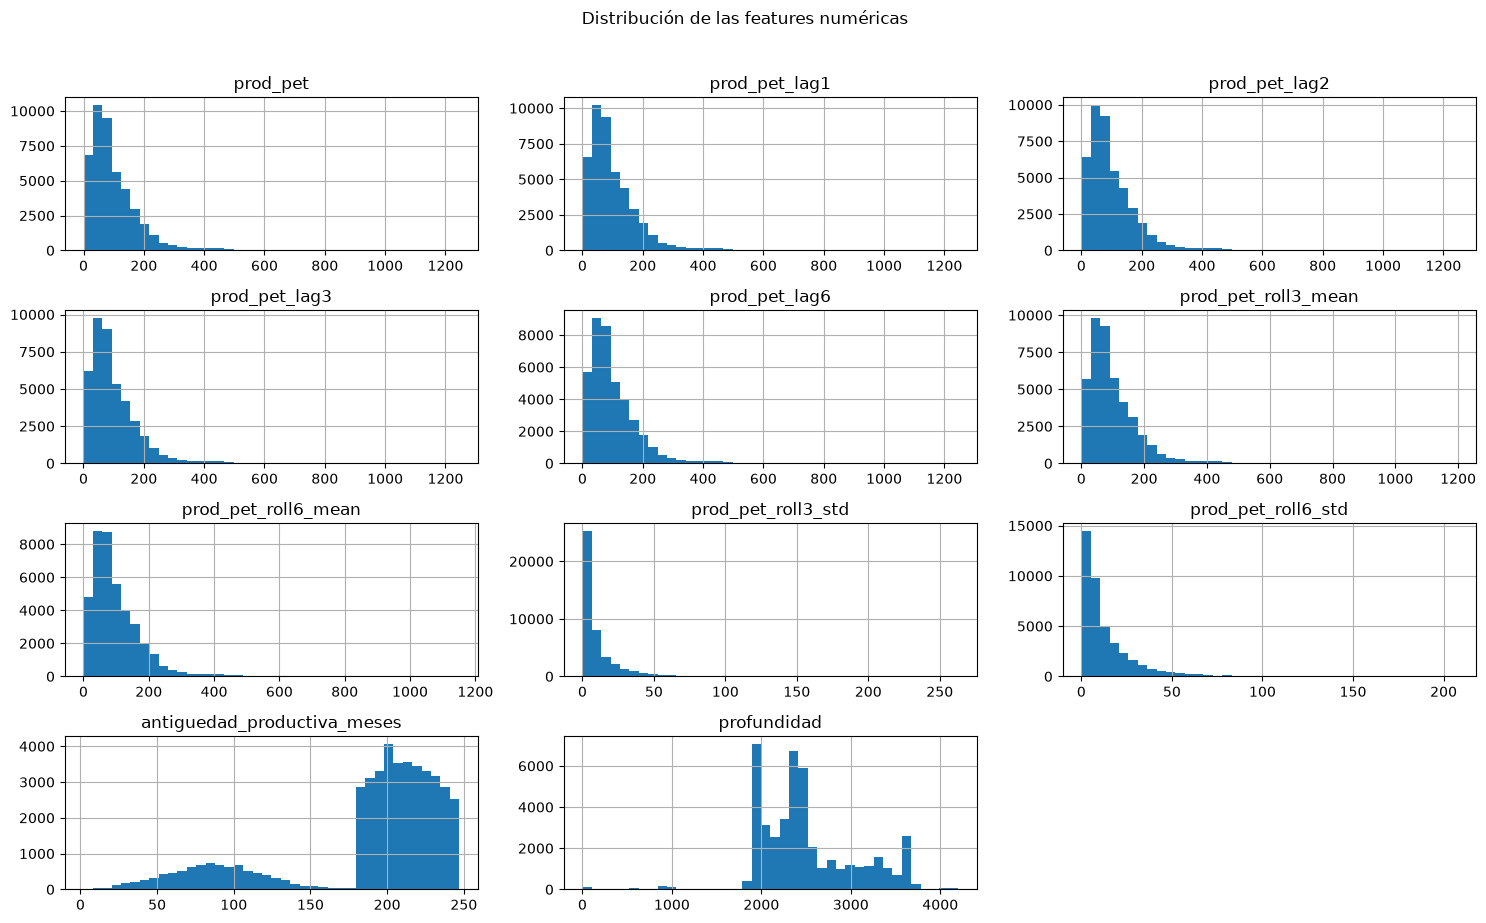

In [51]:
print(df[FEATURES_NUM].describe().T[["mean", "50%", "std", "max"]].round(2))
print("\nAsimetría (skew):")
print(df[FEATURES_NUM].skew().round(2))

df[FEATURES_NUM].hist(bins=40, figsize=(15, 9))
plt.suptitle("Distribución de las features numéricas", y=1.02)
plt.tight_layout(); plt.show()

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

def armar_pipelines():
    """Devuelve un pipeline nuevo por modelo (preprocesamiento + modelo). Se ajustan solo con train."""
    def nuevo_ohe():
        return OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False)
    cat = [("cat", nuevo_ohe(), FEATURES_CAT_FINAL)] if FEATURES_CAT_FINAL else []
    pre_lineal = ColumnTransformer([("num", StandardScaler(), FEATURES_NUM)] + cat)
    pre_arbol = ColumnTransformer([("num", "passthrough", FEATURES_NUM)] + cat)
    return {
        "lineal": Pipeline([("prep", pre_lineal), ("modelo", LinearRegression())]),
        "random_forest": Pipeline([("prep", pre_arbol),
                                   ("modelo", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    }

# Prueba de humo con H1 (solo verifica que los pipelines corren; las métricas se evalúan en las cards de entrenamiento)
from sklearn.metrics import mean_absolute_error
tr, te = split_temporal(df, 1)
X_cols = FEATURES_NUM + FEATURES_CAT_FINAL
for nombre, pipe in armar_pipelines().items():
    pipe.fit(tr[X_cols], tr["target_1m"])
    mae = mean_absolute_error(te["target_1m"], pipe.predict(te[X_cols]))
    print(f"{nombre}: OK | MAE H1 test (prueba de humo) = {mae:.2f}")

lineal: OK | MAE H1 test (prueba de humo) = 11.67
random_forest: OK | MAE H1 test (prueba de humo) = 12.46


### Criterio de escalado

| Modelo | ¿Escalar? | Motivo |
|---|---|---|
| Persistencia | No aplica | Repite el último valor observado |
| Regresión lineal | Sí (`StandardScaler`) | Coeficientes comparables; necesario si se agrega regularización |
| Random Forest / Gradient Boosting | No | Los árboles no dependen de la escala de las variables |

**Revisión de distribuciones:**
- Las variables de producción (`prod_pet`, lags y medias móviles) tienen una fuerte asimetría a la derecha (skew ≈ 3,8): mediana ≈ 78–80 m³, media ≈ 101–103 m³ y máximos de hasta 1.245,6 m³. Las desviaciones móviles son aún más asimétricas (skew 3,4–4,2) y se concentran cerca de 0, es decir, la mayoría de los pozos tiene producción estable mes a mes.
- `profundidad` (media 2.499 m, mediana 2.400 m) es casi simétrica (skew 0,30) pero multimodal, y entra como feature numérica (cumple el criterio de <5% de nulos y variabilidad).
- `antiguedad_productiva_meses` es bimodal (skew −1,38): ver el análisis de censura en enero de 2006.
- `StandardScaler` centra y escala, pero no corrige la asimetría. Para la regresión lineal queda como mejora opcional probar `log1p` en features y target, y comparar contra la versión sin transformar.
- Prueba de humo (H1, test 2025): regresión lineal MAE = 11,67; Random Forest MAE = 12,46. Solo verifica que los pipelines funcionan; la comparación formal (contra persistencia y por horizonte) se hace en la etapa de modelado(corrida con antigüedad; ver decisión posterior)

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

COL_ANT = "antiguedad_productiva_meses"
df["inicio_censurado"] = (df["fecha_primera_produccion"] == pd.Timestamp("2006-01-01")).astype(int)
df["antiguedad_real"] = df[COL_ANT].where(df["inicio_censurado"] == 0, -1)   # -1 = desconocida
print("Pozos por inicio_censurado:\n", df.groupby("inicio_censurado")["idpozo"].nunique())

base_num = [c for c in FEATURES_NUM if c != COL_ANT]
variantes = {
    "actual (antigüedad tal cual)": base_num + [COL_ANT],
    "sin antigüedad": base_num,
    "antigüedad real + flag censura": base_num + ["antiguedad_real", "inicio_censurado"],
}

def pipe(num, lineal):
    pre = ColumnTransformer([
        ("num", StandardScaler() if lineal else "passthrough", num),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01,
                              sparse_output=False), FEATURES_CAT_FINAL)])
    modelo = LinearRegression() if lineal else RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    return Pipeline([("prep", pre), ("modelo", modelo)])

filas = []
for nombre, num in variantes.items():
    tr, te = split_temporal(df, 1, features=num)
    for mod, lineal in [("lineal", True), ("random_forest", False)]:
        p = pipe(num, lineal).fit(tr[num + FEATURES_CAT_FINAL], tr["target_1m"])
        filas.append({"variante": nombre, "modelo": mod, "test_filas": len(te),
                      "MAE_H1": mean_absolute_error(te["target_1m"], p.predict(te[num + FEATURES_CAT_FINAL]))})
res_ant = pd.DataFrame(filas)
print(res_ant.pivot(index="variante", columns="modelo", values="MAE_H1").round(2))
print("Filas de test por variante:", res_ant.groupby("variante")["test_filas"].first().to_dict())

Pozos por inicio_censurado:
 inicio_censurado
0    169
1    682
Name: idpozo, dtype: int64
modelo                          lineal  random_forest
variante                                             
actual (antigüedad tal cual)     11.67          12.43
antigüedad real + flag censura   11.68          12.13
sin antigüedad                   11.68          12.09
Filas de test por variante: {'actual (antigüedad tal cual)': 7606, 'antigüedad real + flag censura': 7606, 'sin antigüedad': 7606}


### ANTIGUEDAD

In [54]:
# Decisión: se excluye la antigüedad (para el 80% de los pozos es "meses desde ene-2006")
FEATURES_NUM = [c for c in FEATURES_NUM if c != "antiguedad_productiva_meses"]
print("FEATURES_NUM final:", FEATURES_NUM)

FEATURES_NUM final: ['prod_pet', 'prod_pet_lag1', 'prod_pet_lag2', 'prod_pet_lag3', 'prod_pet_lag6', 'prod_pet_roll3_mean', 'prod_pet_roll6_mean', 'prod_pet_roll3_std', 'prod_pet_roll6_std', 'profundidad']


### Decisión sobre `antiguedad_productiva_meses`

- 682 de 851 pozos maduros (80,1%) tienen como primera producción enero de 2006, que es el inicio del registro y no el inicio real del pozo. Para ellos la variable equivale a "meses desde enero de 2006", es decir, a la fecha calendario. Solo 169 pozos tienen una fecha de inicio real. Por eso el histograma es bimodal.
- Por construcción, en train (hasta nov-2024) esos pozos alcanzan como máximo 226 meses; en test 2025 valen entre 228 y 239, fuera del rango visto en entrenamiento.
- Verificación empírica (H1, test 2025, mismas 7.606 filas): MAE regresión lineal 11,67 (con antigüedad) / 11,68 (con antigüedad real + flag de censura) / 11,68 (sin antigüedad); Random Forest 12,43 / 12,13 / 12,09.
- **Decisión:** se excluye del modelo principal. La regresión lineal no cambia y el Random Forest mejora levemente sin ella. La variante con antigüedad real y flag de censura no supera a la más simple. Las diferencias son pequeñas (una sola semilla), por lo que la decisión se apoya sobre todo en el argumento conceptual.
- Features numéricas finales: `prod_pet`, lags 1/2/3/6, medias y desviaciones móviles de 3 y 6 meses, y `profundidad`.

## Cálculo de `meses_hasta_pico` (análisis complementario)

Tras la devolución docente, `meses_hasta_pico` deja de ser el target principal. Se calcula como análisis de maduración: mes de máxima producción observada por pozo, menos la fecha de primera producción del padrón. Se filtran los pozos sin historial suficiente: los que comenzaron antes de la ventana observada (el pico observado no es el pico real) y los que no tienen un mínimo de meses posteriores al pico (el pico podría no haberse alcanzado todavía).

In [55]:
# Chequeo previo: ¿cuántos pozos tienen como primera producción enero de 2006 (fecha artificial)?
print("Columnas del padrón:", padron.columns.tolist())
ini = padron[["idpozo", "anio", "mes"]].rename(columns={"anio": "anio_ini", "mes": "mes_ini"})
ini_maduros = ini[ini["idpozo"].isin(df["idpozo"].unique())]
n2006 = ((ini_maduros["anio_ini"] == 2006) & (ini_maduros["mes_ini"] == 1)).sum()
print(f"Pozos maduros con primera producción = enero 2006: {n2006} de {len(ini_maduros)} ({n2006/len(ini_maduros):.1%})")

Columnas del padrón: ['idpozo', 'anio', 'mes', 'fecha_primera_produccion']
Pozos maduros con primera producción = enero 2006: 682 de 851 (80.1%)


In [56]:
MIN_MESES_POST_PICO = 6     # criterio ajustable: meses observados después del pico para considerarlo confiable

base = df_cuyana[["idpozo", "anio", "mes", "prod_pet"]].copy()
base["fecha"] = pd.to_datetime(dict(year=base["anio"], month=base["mes"], day=1))
base = base.sort_values(["idpozo", "fecha"]).reset_index(drop=True)

idx_pico = base.groupby("idpozo")["prod_pet"].idxmax()
pico = (base.loc[idx_pico, ["idpozo", "fecha", "prod_pet"]]
        .rename(columns={"fecha": "fecha_pico", "prod_pet": "prod_pico"}))
pico = pico.merge(ini, on="idpozo", how="left")
pico["ultima_fecha"] = pico["idpozo"].map(base.groupby("idpozo")["fecha"].max())

pico["meses_hasta_pico"] = ((pico["fecha_pico"].dt.year - pico["anio_ini"]) * 12
                            + (pico["fecha_pico"].dt.month - pico["mes_ini"]))
pico["meses_post_pico"] = ((pico["ultima_fecha"].dt.year - pico["fecha_pico"].dt.year) * 12
                           + (pico["ultima_fecha"].dt.month - pico["fecha_pico"].dt.month))

pico["confiable"] = ((pico["anio_ini"] >= 2021)                         # el inicio cae dentro de la ventana observada
                     & (pico["meses_hasta_pico"] >= 0)
                     & (pico["meses_post_pico"] >= MIN_MESES_POST_PICO)  # historial suficiente después del pico
                     & (pico["prod_pico"] > 0))

pico["es_maduro_modelo"] = pico["idpozo"].isin(df["idpozo"].unique())
resumen = pico.groupby("es_maduro_modelo")["confiable"].agg(total="size", confiables="sum")
print(resumen)

pico_ok = pico[pico["confiable"]]
print("\nDistribución de meses_hasta_pico (pozos confiables):")
print(pico_ok["meses_hasta_pico"].describe().round(1))

os.makedirs("../data/processed", exist_ok=True)
pico.to_csv("../data/processed/meses_hasta_pico_pozos.csv", index=False)

                  total  confiables
es_maduro_modelo                   
False              2851           6
True                851           5

Distribución de meses_hasta_pico (pozos confiables):
count    11.0
mean      9.3
std       7.1
min       4.0
25%       4.0
50%       8.0
75%       9.0
max      23.0
Name: meses_hasta_pico, dtype: float64


In [57]:
# ¿Puede usarse como feature? Evidencia de leakage: el pico global cambia según hasta dónde se mire
corte = pd.Period("2024-12", "M")
sub = df[df[COL_FECHA].dt.to_period("M") <= corte]
max_global = df.groupby("idpozo")["prod_pet"].max()
max_hasta_corte = sub.groupby("idpozo")["prod_pet"].max()
cambia = (max_global.loc[max_hasta_corte.index] > max_hasta_corte).mean()
print(f"{cambia:.1%} de los pozos tienen su máximo de producción DESPUÉS de dic-2024: "
      "usar el pico global como feature filtraría información futura.")

17.2% de los pozos tienen su máximo de producción DESPUÉS de dic-2024: usar el pico global como feature filtraría información futura.


In [58]:
# Alternativa sin leakage: el máximo acumulado hasta el mes t (solo usa información pasada)
df["max_acum"] = df.groupby("idpozo")["prod_pet"].cummax()
df["ratio_vs_max_acum"] = df["prod_pet"] / df["max_acum"]
df["nuevo_max"] = (df["prod_pet"] >= df["max_acum"]).astype(int)
df["grupo_max"] = df.groupby("idpozo")["nuevo_max"].cumsum()
df["meses_desde_max_acum"] = df.groupby(["idpozo", "grupo_max"]).cumcount()


# Verificación: recalcular solo con datos hasta el corte debe dar lo mismo que la columna del df completo
a = sub.groupby("idpozo")["prod_pet"].cummax()
assert np.allclose(df.loc[a.index, "max_acum"], a), "max_acum usa información futura"
print("max_acum: OK (no usa información futura)")

max_acum: OK (no usa información futura)


### Conclusión: `meses_hasta_pico`

- Se calculó el mes de máxima producción observada por pozo y su diferencia con la primera producción del padrón. Con el criterio de confiabilidad (inicio dentro de la ventana 2021–2026, `meses_hasta_pico >= 0`, al menos 6 meses observados después del pico y `prod_pico > 0`), solo **11 de 3.702 pozos** resultan confiables: 5 de los 851 pozos maduros del modelo y 6 de los 2.851 restantes. En ellos, `meses_hasta_pico` tiene una mediana de 8 meses (media 9,3; rango 4–23).
- La causa principal es la censura a la izquierda: **682 de los 851 pozos maduros (80,1%)** tienen como primera producción enero de 2006, una fecha artificial. Para esos pozos el pico observado no es el pico real.
- Con 11 casos, la variable no sirve como target ni permite conclusiones generales. Queda como **análisis descriptivo de maduración** de los pocos pozos nuevos.
- **No se incorpora al modelo:** calculada sobre toda la serie usa información posterior al origen de predicción. El 17,2% de los pozos tiene su máximo de producción después de diciembre de 2024, por lo que el pico global filtraría información del futuro. La alternativa calculable en el mes t (`max_acum`, `ratio_vs_max_acum`, `meses_desde_max_acum`) pasó la verificación de no usar información futura, pero representa el máximo observado desde 2021, no el de vida del pozo. No se incluye en el modelo principal.

# Modelo baseline t+1

Se entrena un modelo simple para predecir la producción del mes siguiente (`target_1m`, H1) y obtener métricas de referencia. Split temporal: train 2021-2024 (con purga), test 2025. Se comparan persistencia, regresión lineal y árbol simple.

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import clone

df["target_prod_pet_sig_mes"] = df["target_1m"]   # nombre del backlog; NO usar como feature

def metricas(y, p):
    return {"MAE": mean_absolute_error(y, p),
            "RMSE": np.sqrt(mean_squared_error(y, p)),
            "R2": r2_score(y, p),
            "WAPE": np.abs(y - p).sum() / y.sum()}

tr, te = split_temporal(df, 1)
X_cols = FEATURES_NUM + FEATURES_CAT_FINAL
y_tr, y_te = tr["target_1m"], te["target_1m"]

modelos = {
    "Persistencia": None,
    "Regresión lineal": armar_pipelines()["lineal"],
    "Árbol simple (max_depth=5)": clone(armar_pipelines()["random_forest"]).set_params(
        modelo=DecisionTreeRegressor(max_depth=5, random_state=42)),
}

filas, preds = [], {}
for nombre, m in modelos.items():
    if m is None:
        p_tr, p_te = tr["prod_pet"], te["prod_pet"]
    else:
        m.fit(tr[X_cols], y_tr)
        p_tr, p_te = m.predict(tr[X_cols]), m.predict(te[X_cols])
    preds[nombre] = p_te
    filas.append({"modelo": nombre, "set": "train", **metricas(y_tr, p_tr)})
    filas.append({"modelo": nombre, "set": "test",  **metricas(y_te, p_te)})

resultados_baseline = pd.DataFrame(filas).round(3)
print(resultados_baseline.to_string(index=False))

                    modelo   set    MAE   RMSE    R2  WAPE
              Persistencia train 11.535 23.142 0.940 0.113
              Persistencia  test 12.178 25.600 0.899 0.130
          Regresión lineal train 11.299 21.682 0.948 0.110
          Regresión lineal  test 11.677 23.969 0.911 0.125
Árbol simple (max_depth=5) train 12.504 22.017 0.946 0.122
Árbol simple (max_depth=5)  test 13.271 25.001 0.903 0.142


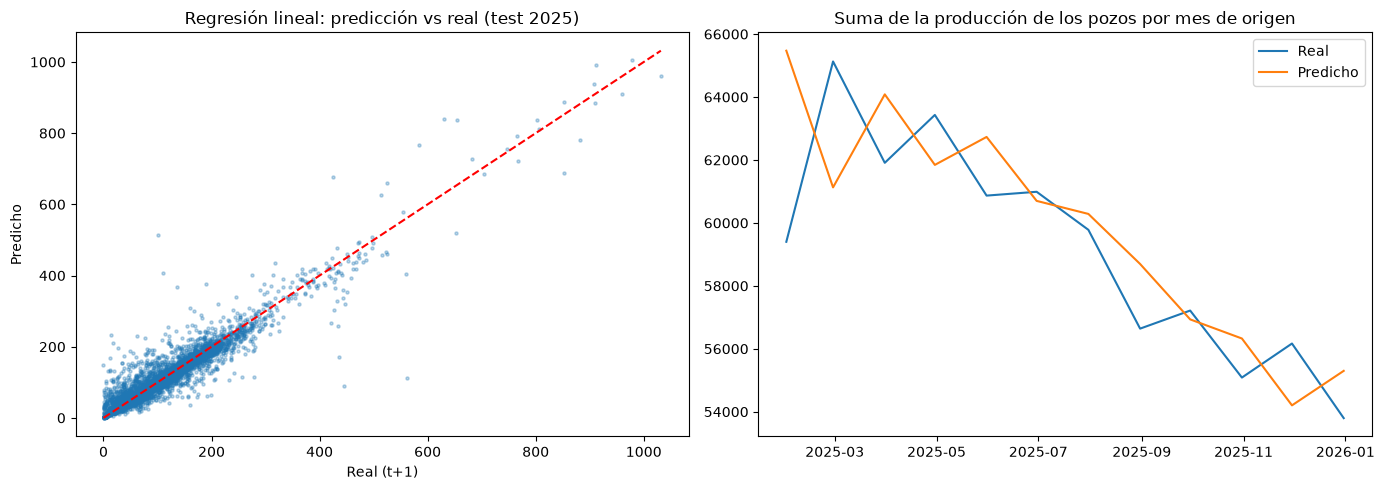

Predicciones negativas (regresión lineal): 3


In [60]:
nombre = "Regresión lineal"
pred = preds[nombre]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_te, pred, s=5, alpha=0.3)
lim = [0, max(y_te.max(), np.max(pred))]
ax[0].plot(lim, lim, "r--"); ax[0].set_xlabel("Real (t+1)"); ax[0].set_ylabel("Predicho")
ax[0].set_title(f"{nombre}: predicción vs real (test 2025)")

mensual = te.assign(real=y_te, pred=pred).groupby(COL_FECHA)[["real", "pred"]].sum()
ax[1].plot(mensual.index, mensual["real"], label="Real")
ax[1].plot(mensual.index, mensual["pred"], label="Predicho")
ax[1].set_title("Suma de la producción de los pozos por mes de origen"); ax[1].legend()
plt.tight_layout(); plt.show()

print("Predicciones negativas (regresión lineal):", (pred < 0).sum())

### Resultados del baseline t+1 (H1, test 2025)

| Modelo | Set | MAE | RMSE | R² | WAPE |
|---|---|---|---|---|---|
| Persistencia | train | 11,535 | 23,142 | 0,940 | 11,3% |
| Persistencia | test | 12,178 | 25,600 | 0,899 | 13,0% |
| Regresión lineal | train | 11,299 | 21,682 | 0,948 | 11,0% |
| Regresión lineal | test | 11,677 | 23,969 | 0,911 | 12,5% |
| Árbol simple (max_depth=5) | train | 12,504 | 22,017 | 0,946 | 12,2% |
| Árbol simple (max_depth=5) | test | 13,271 | 25,001 | 0,903 | 14,2% |

- **La persistencia es un baseline muy fuerte** (R² = 0,899 en test): la producción de un pozo maduro cambia poco de un mes al siguiente.
- **La regresión lineal es el mejor modelo en H1**, pero la mejora es modesta: baja el MAE de 12,18 a 11,68 (aprox. 4%) y el RMSE de 25,60 a 23,97 (aprox. 6%). El WAPE pasa de 13,0% a 12,5%.
- **El árbol simple (profundidad 5) no supera a la persistencia en MAE** (13,27 contra 12,18), aunque tiene un RMSE algo menor (25,00 contra 25,60).
- **Sin señales de overfitting:** la diferencia train–test es chica (regresión lineal: MAE 11,30 a 11,68). La persistencia, que no se entrena, también empeora en test (11,54 a 12,18), así que parte de esa diferencia se debe al período y no al ajuste.
- **Predicción vs real:** los puntos se alinean con la diagonal y hay pocos casos extremos mal predichos. La suma mensual predicha sigue la caída de la producción real durante 2025, con un leve desfase respecto de la curva real.
- **Predicciones negativas (regresión lineal): 3.** Es un número muy bajo, pero hay que tenerlo en cuenta (se puede truncar en 0).
- Estas métricas son la **referencia para comparar H2–H6**. Pueden ser algo optimistas, porque el criterio de pozo maduro mira la historia completa (limitación ya documentada en la sección de leakage).

# Sprint 4 — Modelado supervisado (continuación)

**Objetivo:** predecir la producción futura de petróleo de un pozo maduro de la Cuenca Cuyana, para horizontes de **1 a 6 meses (H1–H6)**.

Esta sección continúa el trabajo anterior. **No modifica** las features, los targets ni las decisiones que ya tomó el equipo:

- Se mantiene `areayacimiento` y **no** se incorpora `empresa` ni `antiguedad_productiva_meses`.
- Usamos las funciones ya creadas: `split_temporal()`, `armar_pipelines()` y `metricas()`.
- Comparamos **persistencia** (repetir el valor actual), **regresión lineal**, **Random Forest** y **k-NN**.
- Para que H1–H6 sean comparables, el test usa **los mismos registros de enero a junio de 2025**, con targets conocidos hasta diciembre de 2025. Esto es diferente del test H1 de año completo de la sección anterior.
- Ajustamos una sola característica de Random Forest (`max_depth`) mediante una validación temporal: entrenamiento hasta 2023 y validación en 2024. **2025 no se usa para elegir hiperparámetros.**

**Para ejecutar:** corré primero las celdas anteriores del notebook, en orden. Los números finales de este Sprint aparecen al ejecutar las celdas con los archivos reales; no se completan de antemano.

## 1. Preparar la comparación y recuperar el baseline

Antes de entrenar verificamos las columnas. La **persistencia** es una referencia útil: supone que el pozo producirá lo mismo que produce hoy. El baseline H1 ya fue calculado en la sección anterior, por eso lo reutilizamos.

In [61]:
from sklearn.base import clone
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error

# Reutilizamos nombres del notebook anterior; nuestras variables empiezan con s4_.
s4_features = FEATURES_NUM + FEATURES_CAT_FINAL
s4_targets = [f"target_{h}m" for h in range(1, 7)]
s4_necesarias = ["idpozo", COL_FECHA] + s4_features + s4_targets
s4_faltantes = [c for c in s4_necesarias if c not in df.columns]
assert not s4_faltantes, f"Faltan columnas: {s4_faltantes}"

# Mismos registros para comparar H1, H2, ..., H6. Evitamos targets de 2026.
s4_periodo = df[COL_FECHA].dt.to_period("M")
s4_test = df[(s4_periodo >= "2025-01") & (s4_periodo <= "2025-06")].copy()
s4_test = s4_test.dropna(subset=s4_features + s4_targets)
assert len(s4_test) > 0, "No hay datos para el test común de 2025."
print("Test común:", len(s4_test), "filas y", s4_test["idpozo"].nunique(), "pozos")
print("Desde:", s4_test[COL_FECHA].min().date(), "hasta:", s4_test[COL_FECHA].max().date())
print("Features usadas:", s4_features)
print("\nBaseline H1 original (test 2025 completo, NO el test común):")
print(resultados_baseline.to_string(index=False))

Test común: 3700 filas y 649 pozos
Desde: 2025-01-31 hasta: 2025-06-30
Features usadas: ['prod_pet', 'prod_pet_lag1', 'prod_pet_lag2', 'prod_pet_lag3', 'prod_pet_lag6', 'prod_pet_roll3_mean', 'prod_pet_roll6_mean', 'prod_pet_roll3_std', 'prod_pet_roll6_std', 'profundidad', 'areayacimiento']

Baseline H1 original (test 2025 completo, NO el test común):
                    modelo   set    MAE   RMSE    R2  WAPE
              Persistencia train 11.535 23.142 0.940 0.113
              Persistencia  test 12.178 25.600 0.899 0.130
          Regresión lineal train 11.299 21.682 0.948 0.110
          Regresión lineal  test 11.677 23.969 0.911 0.125
Árbol simple (max_depth=5) train 12.504 22.017 0.946 0.122
Árbol simple (max_depth=5)  test 13.271 25.001 0.903 0.142


## 2. Entrenar y comparar modelos H1–H6

**¿Por qué estos modelos?** La regresión lineal da una referencia fácil de interpretar. Random Forest combina varios árboles y puede aprender relaciones no lineales. k-NN predice a partir de registros parecidos, por eso sus variables numéricas se **escalan**. No incluimos SVR en esta primera comparación para mantener el análisis acotado y comprensible; es una alternativa futura, no un requisito para un modelo válido.

**Métricas:** el **MAE** es el error absoluto promedio, expresado en **m³/mes** (más bajo es mejor). El **RMSE** también mide error, pero penaliza más los errores grandes (más bajo es mejor). **R²** compara con predecir siempre la media (más alto suele ser mejor; puede ser negativo).

Las transformaciones numéricas y el One-Hot de `areayacimiento` se ajustan **solo con entrenamiento** porque cada modelo usa un `Pipeline`.

In [62]:
s4_filas = []
s4_pred_h1 = {}          # Guardamos predicciones de H1 para el gráfico posterior.
s4_rf_h1 = None         # Guardamos solo el RF de H1 para ver importancia de variables.

for h in range(1, 7):
    s4_train, _ = split_temporal(df, h)  # Entrenamiento hasta 2024, con purga por horizonte.
    s4_y_train = s4_train[f"target_{h}m"]
    s4_y_test = s4_test[f"target_{h}m"]

    # k-NN: escalamos valores numéricos, igual que en el pipeline lineal.
    s4_pre_knn = ColumnTransformer([
        ("num", StandardScaler(), FEATURES_NUM),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist",
                              min_frequency=0.01, sparse_output=False), FEATURES_CAT_FINAL)
    ])
    s4_modelos = {
        "Regresión lineal": armar_pipelines()["lineal"],
        "Random Forest": armar_pipelines()["random_forest"],
        "k-NN": Pipeline([("prep", s4_pre_knn),
                           ("modelo", KNeighborsRegressor(n_neighbors=5))]),
    }

    # Persistencia: no se entrena ningún modelo.
    for s4_set, s4_y, s4_pred in [
        ("train", s4_y_train, s4_train["prod_pet"]),
        ("test", s4_y_test, s4_test["prod_pet"]),
    ]:
        s4_filas.append({"horizonte": h, "modelo": "Persistencia", "set": s4_set,
                         **metricas(s4_y, s4_pred)})
    if h == 1:
        s4_pred_h1["Persistencia"] = s4_test["prod_pet"].to_numpy()

    for s4_nombre, s4_modelo in s4_modelos.items():
        s4_modelo.fit(s4_train[s4_features], s4_y_train)
        for s4_set, s4_datos, s4_y in [
            ("train", s4_train, s4_y_train),
            ("test", s4_test, s4_y_test),
        ]:
            s4_pred = s4_modelo.predict(s4_datos[s4_features])
            s4_filas.append({"horizonte": h, "modelo": s4_nombre, "set": s4_set,
                             **metricas(s4_y, s4_pred)})
            if h == 1 and s4_set == "test":
                s4_pred_h1[s4_nombre] = s4_pred
        if h == 1 and s4_nombre == "Random Forest":
            s4_rf_h1 = s4_modelo

s4_resultados = pd.DataFrame(s4_filas)
print("MAE por horizonte en el MISMO test (ene-jun de 2025):")
print(s4_resultados[s4_resultados["set"] == "test"]
      .pivot(index="horizonte", columns="modelo", values="MAE").round(2).to_string())
print("\nMétricas completas (test):")
print(s4_resultados[s4_resultados["set"] == "test"]
      [["horizonte", "modelo", "MAE", "RMSE", "R2"]].round(3).to_string(index=False))

MAE por horizonte en el MISMO test (ene-jun de 2025):
modelo     Persistencia  Random Forest  Regresión lineal   k-NN
horizonte                                                      
1                 12.47          11.82             11.48  13.88
2                 14.48          14.28             13.55  16.77
3                 17.01          16.34             15.57  18.63
4                 18.64          17.91             17.06  20.08
5                 20.21          18.90             18.28  21.63
6                 22.01          20.60             20.09  23.29

Métricas completas (test):
 horizonte           modelo    MAE   RMSE    R2
         1     Persistencia 12.472 26.453 0.902
         1 Regresión lineal 11.478 24.545 0.915
         1    Random Forest 11.815 24.567 0.915
         1             k-NN 13.883 26.794 0.899
         2     Persistencia 14.484 30.005 0.874
         2 Regresión lineal 13.548 27.422 0.895
         2    Random Forest 14.283 28.435 0.887
         2            

## 3. Visualizar resultados y revisar overfitting

El gráfico de MAE permite ver si el error aumenta al predecir más meses hacia adelante. Para revisar **overfitting** comparamos MAE de *train* y *test*: cuando el error de test es claramente mayor que el de train, puede indicar que el modelo aprendió demasiado los datos de entrenamiento. **No es una prueba definitiva**, porque los períodos también pueden ser diferentes.

No usamos K-Fold aleatorio, ya que podría mezclar meses futuros con meses pasados.

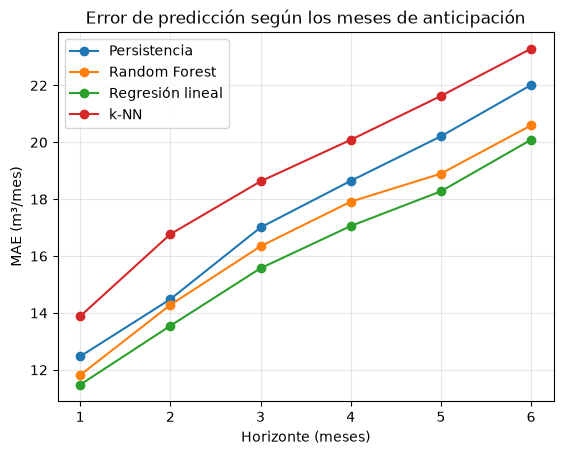

Overfitting (MAE train vs test; diferencia positiva = error mayor en test):
 horizonte           modelo  test  train  diferencia_test_train
         1     Persistencia 12.47  11.54                   0.94
         1    Random Forest 11.82   4.30                   7.51
         1 Regresión lineal 11.48  11.30                   0.18
         1             k-NN 13.88  10.65                   3.23
         2     Persistencia 14.48  14.69                  -0.21
         2    Random Forest 14.28   5.26                   9.03
         2 Regresión lineal 13.55  14.34                  -0.79
         2             k-NN 16.77  12.52                   4.25
         3     Persistencia 17.01  16.98                   0.03
         3    Random Forest 16.34   5.89                  10.45
         3 Regresión lineal 15.57  16.23                  -0.66
         3             k-NN 18.63  13.63                   4.99
         4     Persistencia 18.64  18.83                  -0.19
         4    Random Forest 

In [63]:
s4_test_tabla = s4_resultados[s4_resultados["set"] == "test"]
for s4_nombre, s4_grupo in s4_test_tabla.groupby("modelo"):
    plt.plot(s4_grupo["horizonte"], s4_grupo["MAE"], marker="o", label=s4_nombre)
plt.title("Error de predicción según los meses de anticipación")
plt.xlabel("Horizonte (meses)")
plt.ylabel("MAE (m³/mes)")
plt.xticks(range(1, 7))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Diferencia entre error de entrenamiento y prueba en cada horizonte.
s4_overfitting = s4_resultados.pivot(index=["horizonte", "modelo"],
                                     columns="set", values="MAE").reset_index()
s4_overfitting["diferencia_test_train"] = s4_overfitting["test"] - s4_overfitting["train"]
print("Overfitting (MAE train vs test; diferencia positiva = error mayor en test):")
print(s4_overfitting.round(2).to_string(index=False))

## 4. Ajustar un hiperparámetro de Random Forest

Un **hiperparámetro** se elige antes de entrenar. Probaremos solo `max_depth`, que indica cuánta profundidad pueden tener los árboles. Un árbol muy profundo puede ajustarse demasiado al entrenamiento; uno muy poco profundo puede quedarse corto.

Para elegirlo sin mirar el test 2025, usamos:

- **Entrenamiento interno:** observaciones cuyo target ya se conocía hasta diciembre de 2023.
- **Validación:** observaciones de 2024 cuyo target se conoce hasta diciembre de 2024.

En cada horizonte probamos profundidades **6, 12 y sin límite (`None`)**. Elegimos la de menor MAE de validación. Es una validación temporal simple, en lugar de una búsqueda automática extensa.

In [64]:
s4_pruebas = []
s4_mejor_profundidad = {}

for h in range(1, 7):
    s4_train, _ = split_temporal(df, h)
    s4_mes = s4_train[COL_FECHA].dt.to_period("M")
    s4_entrena = s4_train[(s4_mes + h) <= pd.Period("2023-12", "M")]
    s4_valida = s4_train[(s4_mes >= "2024-01") & (s4_mes <= "2024-12")]
    assert len(s4_entrena) > 0 and len(s4_valida) > 0, f"H{h}: falta train o validación"

    for s4_prof in [6, 12, None]:
        s4_modelo = armar_pipelines()["random_forest"]
        s4_modelo.set_params(modelo__max_depth=s4_prof)
        s4_modelo.fit(s4_entrena[s4_features], s4_entrena[f"target_{h}m"])
        s4_pred = s4_modelo.predict(s4_valida[s4_features])
        s4_mae = mean_absolute_error(s4_valida[f"target_{h}m"], s4_pred)
        s4_pruebas.append({"horizonte": h, "profundidad": str(s4_prof),
                           "MAE_validacion_2024": s4_mae})

    # Buscamos la mejor profundidad usando SOLO validación de 2024.
    s4_opciones = [fila for fila in s4_pruebas if fila["horizonte"] == h]
    s4_mejor = min(s4_opciones, key=lambda fila: fila["MAE_validacion_2024"])
    s4_mejor_profundidad[h] = None if s4_mejor["profundidad"] == "None" else int(s4_mejor["profundidad"])

print("Pruebas de hiperparámetros (menor MAE es mejor):")
print(pd.DataFrame(s4_pruebas).round(2).to_string(index=False))
print("\nProfundidad elegida por horizonte:", s4_mejor_profundidad)

Pruebas de hiperparámetros (menor MAE es mejor):
 horizonte profundidad  MAE_validacion_2024
         1           6                10.93
         1          12                10.84
         1        None                11.28
         2           6                13.60
         2          12                13.64
         2        None                14.18
         3           6                15.43
         3          12                15.55
         3        None                16.15
         4           6                16.87
         4          12                16.83
         4        None                17.47
         5           6                17.63
         5          12                17.73
         5        None                18.34
         6           6                18.25
         6          12                18.46
         6        None                19.06

Profundidad elegida por horizonte: {1: 12, 2: 6, 3: 6, 4: 12, 5: 6, 6: 6}


## 5. Evaluar Random Forest ajustado (sin volver a elegir con test)

Ahora entrenamos nuevamente cada Random Forest con **todo el train permitido de 2021–2024** y con la profundidad elegida usando 2024. Lo evaluamos una sola vez en el **test común de 2025**.

Si el ajuste no supera al Random Forest original, **no lo presentamos como una mejora**. Los resultados del test sirven para comparar lo logrado, no para cambiar otra vez la profundidad.

In [65]:
s4_filas_ajustado = []
s4_rf_h1_ajustado = None

for h in range(1, 7):
    s4_train, _ = split_temporal(df, h)
    s4_modelo = armar_pipelines()["random_forest"]
    s4_modelo.set_params(modelo__max_depth=s4_mejor_profundidad[h])
    s4_modelo.fit(s4_train[s4_features], s4_train[f"target_{h}m"])

    for s4_set, s4_datos in [("train", s4_train), ("test", s4_test)]:
        s4_y = s4_datos[f"target_{h}m"]
        s4_pred = s4_modelo.predict(s4_datos[s4_features])
        s4_filas_ajustado.append({"horizonte": h, "modelo": "Random Forest ajustado",
                                 "set": s4_set, **metricas(s4_y, s4_pred)})
        if h == 1 and s4_set == "test":
            s4_pred_h1["Random Forest ajustado"] = s4_pred
    if h == 1:
        s4_rf_h1_ajustado = s4_modelo

s4_resultados = pd.concat([s4_resultados, pd.DataFrame(s4_filas_ajustado)], ignore_index=True)
s4_final = s4_resultados[s4_resultados["set"] == "test"].copy()
print("Comparación final: test común de 2025")
print(s4_final[["horizonte", "modelo", "MAE", "RMSE", "R2"]]
      .sort_values(["horizonte", "MAE"]).round(2).to_string(index=False))

s4_rf_comparacion = s4_final[s4_final["modelo"].isin(["Random Forest", "Random Forest ajustado"])]
print("\nMAE: RF original frente a RF ajustado")
print(s4_rf_comparacion.pivot(index="horizonte", columns="modelo", values="MAE")
      .round(2).to_string())

Comparación final: test común de 2025
 horizonte                 modelo   MAE  RMSE   R2
         1       Regresión lineal 11.48 24.55 0.92
         1 Random Forest ajustado 11.59 24.43 0.92
         1          Random Forest 11.82 24.57 0.92
         1           Persistencia 12.47 26.45 0.90
         1                   k-NN 13.88 26.79 0.90
         2       Regresión lineal 13.55 27.42 0.89
         2 Random Forest ajustado 13.70 27.59 0.89
         2          Random Forest 14.28 28.44 0.89
         2           Persistencia 14.48 30.01 0.87
         2                   k-NN 16.77 31.15 0.86
         3       Regresión lineal 15.57 30.40 0.86
         3 Random Forest ajustado 15.75 30.67 0.86
         3          Random Forest 16.34 31.42 0.85
         3           Persistencia 17.01 33.96 0.83
         3                   k-NN 18.63 33.88 0.83
         4       Regresión lineal 17.06 32.54 0.84
         4 Random Forest ajustado 17.39 33.24 0.83
         4          Random Forest 17.91 33.6

## 6. Interpretar el modelo y comparar predicción con realidad

La **importancia de variables** de Random Forest indica cuáles utilizó más el conjunto de árboles para construir predicciones. **No demuestra causalidad**.

Para visualizar la predicción vs realidad mostramos **H1** en el test común. Cada punto corresponde a una fila pozo-mes: cuanto más cerca de la diagonal, menor es el error. La curva mensual agrega **solo los pozos presentes en este test**, no toda la Cuenca Cuyana.

Variables de mayor importancia para H1:
num__prod_pet               0.844
num__prod_pet_roll3_mean    0.124
num__prod_pet_lag1          0.007
num__prod_pet_roll6_mean    0.006
num__prod_pet_lag2          0.005
num__prod_pet_lag6          0.003
num__prod_pet_lag3          0.003
num__prod_pet_roll3_std     0.003
num__prod_pet_roll6_std     0.002
num__profundidad            0.002


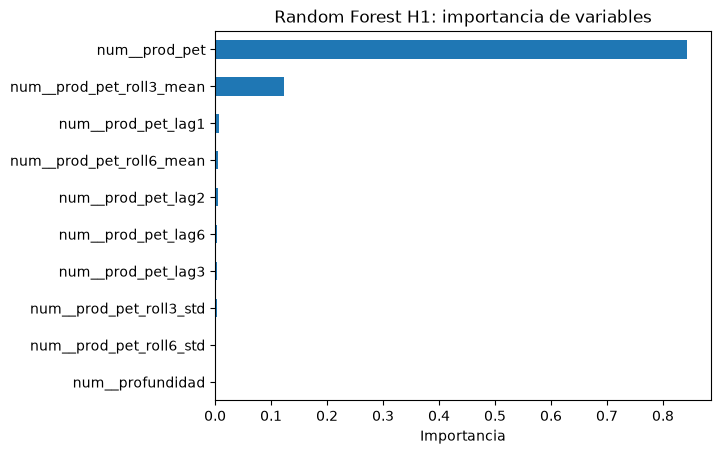

Menor MAE H1 en este test: Regresión lineal


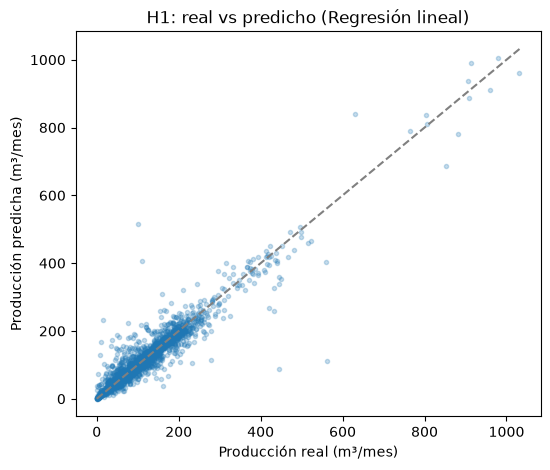

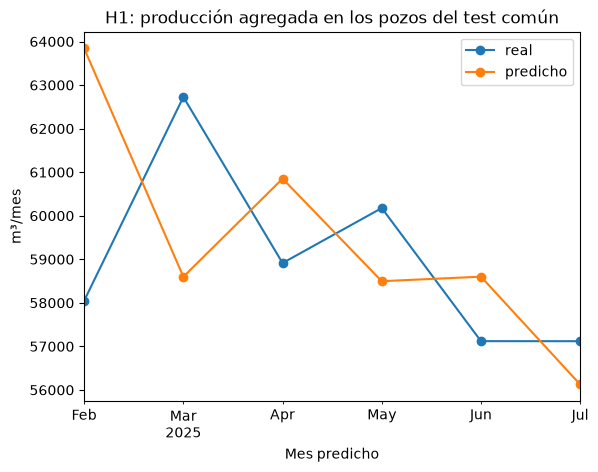

In [66]:
# Importancia de variables del Random Forest ajustado para H1.
s4_nombres = s4_rf_h1_ajustado.named_steps["prep"].get_feature_names_out()
s4_importancia = pd.Series(
    s4_rf_h1_ajustado.named_steps["modelo"].feature_importances_,
    index=s4_nombres
).sort_values(ascending=False).head(10)
print("Variables de mayor importancia para H1:")
print(s4_importancia.round(3).to_string())
s4_importancia.sort_values().plot(kind="barh", title="Random Forest H1: importancia de variables")
plt.xlabel("Importancia")
plt.show()

# Para el ejemplo de H1 elegimos el menor MAE entre los modelos comparados.
s4_h1 = s4_final[s4_final["horizonte"] == 1]
s4_nombre_h1 = s4_h1.sort_values("MAE").iloc[0]["modelo"]
s4_y_h1 = s4_test["target_1m"]
s4_pred_h1_elegida = s4_pred_h1[s4_nombre_h1]
print("Menor MAE H1 en este test:", s4_nombre_h1)

plt.figure(figsize=(6, 5))
plt.scatter(s4_y_h1, s4_pred_h1_elegida, alpha=0.25, s=9)
s4_max = max(s4_y_h1.max(), np.max(s4_pred_h1_elegida))
plt.plot([0, s4_max], [0, s4_max], "--", color="gray")
plt.xlabel("Producción real (m³/mes)")
plt.ylabel("Producción predicha (m³/mes)")
plt.title(f"H1: real vs predicho ({s4_nombre_h1})")
plt.show()

s4_mensual = pd.DataFrame({
    "mes_objetivo": (s4_test[COL_FECHA] + pd.offsets.MonthEnd(1)).to_numpy(),
    "real": s4_y_h1.to_numpy(),
    "predicho": np.asarray(s4_pred_h1_elegida)
}).groupby("mes_objetivo")[["real", "predicho"]].sum()
s4_mensual.plot(marker="o", title="H1: producción agregada en los pozos del test común")
plt.xlabel("Mes predicho")
plt.ylabel("m³/mes")
plt.show()

## 7. Conclusiones, alcance y limitaciones

**Interpretación de negocio:** cada modelo estima cuántos m³ de petróleo podría producir **un pozo maduro individual** en uno a seis meses. La comparación permite estudiar cuánto empeora el pronóstico a medida que nos alejamos de la fecha de origen.

**Clasificación de cortes (card opcional): fuera del alcance de este Sprint.** Para el modelo actual se seleccionaron tramos con `Extracción Efectiva`, `prod_pet > 0` y producción continua. Eso deja fuera muchas interrupciones. No sería correcto crear una clasificación `corte/no corte` usando solo ese dataset; habría que regresar a los datos no filtrados, definir el corte con `tipoestado` y validar las dos clases.

**Limitaciones que deben mencionarse al presentar:**

- El filtrado de pozos maduros mira toda la historia y puede hacer que las métricas sean algo optimistas.
- La composición de operadores cambia en 2025; por eso `empresa` se excluyó de las features.
- Los resultados se calculan sobre un **test común de enero–junio de 2025**, con targets hasta diciembre. No son directamente comparables con los valores H1 del baseline anterior, que usaba todos los orígenes de 2025.
- La validación 2024 es **un único corte temporal**; una evaluación con varios cortes sería una mejora futura.
- Comparar en el mismo test varios modelos da una referencia académica útil, pero elegir continuamente según ese test puede sesgar la estimación de generalización.
- Aunque la guía menciona comparar el enfoque directo con el recursivo, **esa comparación sigue pendiente** hasta contar con sus predicciones sobre idénticos orígenes y pozos. No inventamos sus métricas.

La siguiente celda imprime conclusiones con los **resultados efectivamente obtenidos** al ejecutar el notebook.

In [67]:
# Resumen basado en resultados reales de esta ejecución (no en números supuestos).
s4_ganadores = (s4_final.sort_values("MAE")
                .groupby("horizonte", as_index=False).first()[["horizonte", "modelo", "MAE"]])
print("MODELO CON MENOR MAE POR HORIZONTE (test común 2025)")
print(s4_ganadores.round(2).to_string(index=False))

s4_rf_antes = s4_final[s4_final["modelo"] == "Random Forest"].set_index("horizonte")["MAE"]
s4_rf_despues = s4_final[s4_final["modelo"] == "Random Forest ajustado"].set_index("horizonte")["MAE"]
s4_mejoras = (s4_rf_despues < s4_rf_antes).sum()
print(f"\nEl ajuste de profundidad mejoró el MAE en {s4_mejoras} de 6 horizontes.")

s4_rf_overfit = s4_resultados[s4_resultados["modelo"] == "Random Forest ajustado"]
s4_comparacion_train_test = s4_rf_overfit.pivot(index="horizonte", columns="set", values="MAE")
print("\nMAE del Random Forest ajustado (train vs test):")
print(s4_comparacion_train_test.round(2).to_string())
print("\nCómo interpretarlo: si el error de test supera ampliamente al de train, investigar posible overfitting.")
print("El mejor modelo puede variar según el horizonte; no afirmamos que RF gane siempre.")
print("Pendiente: comparar con el enfoque recursivo usando exactamente el mismo test.")

MODELO CON MENOR MAE POR HORIZONTE (test común 2025)
 horizonte           modelo   MAE
         1 Regresión lineal 11.48
         2 Regresión lineal 13.55
         3 Regresión lineal 15.57
         4 Regresión lineal 17.06
         5 Regresión lineal 18.28
         6 Regresión lineal 20.09

El ajuste de profundidad mejoró el MAE en 6 de 6 horizontes.

MAE del Random Forest ajustado (train vs test):
set         test  train
horizonte              
1          11.59   8.84
2          13.70  13.69
3          15.75  15.49
4          17.39  13.58
5          18.53  17.83
6          20.10  18.81

Cómo interpretarlo: si el error de test supera ampliamente al de train, investigar posible overfitting.
El mejor modelo puede variar según el horizonte; no afirmamos que RF gane siempre.
Pendiente: comparar con el enfoque recursivo usando exactamente el mismo test.
